# StockTwits Sentiment Analysis

This notebook analyzes whether StockTwits sentiment predicts abnormal stock returns.

**Steps:**
1. Read merged files (tweets + CRSP data) year by year
2. Aggregate sentiment at the ticker-date level
3. Merge all years into a single dataset
4. Analyze predictive power of sentiment on abnormal returns

## 1. Setup and Configuration

In [15]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import pickle

# Define paths
merged_folder = r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp"
output_folder = r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated"

# Create output folder
os.makedirs(output_folder, exist_ok=True)

print(f"Reading merged files from: {merged_folder}")
print(f"Output will be saved to: {output_folder}")

Reading merged files from: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp
Output will be saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated


## 2. Aggregate Sentiment at Ticker-Date Level

For each ticker-date combination, we'll calculate:
- **n_tweets**: Total number of tweets
- **n_bullish**: Number of bullish tweets
- **n_bearish**: Number of bearish tweets
- **pct_bullish**: Percentage of bullish tweets
- **pct_bearish**: Percentage of bearish tweets
- **sentiment_score**: (n_bullish - n_bearish) / n_tweets (ranges from -1 to 1)
- **AF_sentiment_score**: log10((1 + n_bullish) / (1 + n_bearish)) - Antweiler and Frank (2004) measure

We'll also keep the abnormal return columns and permno.

In [ ]:
# Get list of merged files
merged_files = sorted([f for f in os.listdir(merged_folder) if f.startswith('merged_') and f.endswith('.csv')])

print(f"Found {len(merged_files)} merged files to process")
print(f"Files: {merged_files[:5]}..." if len(merged_files) > 5 else f"Files: {merged_files}")

# Store aggregated dataframes
aggregated_dfs = []

print(f"\n{'='*60}")
print("Processing files and aggregating sentiment...")
print(f"{'='*60}\n")

for file in tqdm(merged_files, desc="Processing files"):
    file_path = os.path.join(merged_folder, file)
    
    # Read the file
    df = pd.read_csv(file_path)
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Only keep rows where we have a match with CRSP (permno is not null)
    df_matched = df[df['permno'].notna()].copy()
    
    if len(df_matched) == 0:
        print(f"  Warning: {file} has no matched rows, skipping...")
        continue
    
    # Create sentiment indicators
    df_matched['is_bullish'] = (df_matched['sentiment'] == 'Bullish').astype(int)
    df_matched['is_bearish'] = (df_matched['sentiment'] == 'Bearish').astype(int)
    
    # Get abnormal return columns (they start with 'ar_')
    ar_columns = [col for col in df_matched.columns if col.startswith('ar_')]
    
    # Aggregate by symbol and date
    # For AR columns, we take the first value (they should be the same for same ticker-date)
    agg_dict = {
        'permno': 'first',
        'message_id': 'count',  # Count tweets
        'is_bullish': 'sum',
        'is_bearish': 'sum'
    }
    
    # Add AR columns to aggregation (take first value)
    for col in ar_columns:
        agg_dict[col] = 'first'
    
    df_agg = df_matched.groupby(['symbol', 'date']).agg(agg_dict).reset_index()
    
    # Rename columns
    df_agg = df_agg.rename(columns={
        'message_id': 'n_tweets',
        'is_bullish': 'n_bullish',
        'is_bearish': 'n_bearish'
    })
    
    # Calculate sentiment metrics
    df_agg['pct_bullish'] = df_agg['n_bullish'] / df_agg['n_tweets']
    df_agg['pct_bearish'] = df_agg['n_bearish'] / df_agg['n_tweets']
    df_agg['sentiment_score'] = (df_agg['n_bullish'] - df_agg['n_bearish']) / df_agg['n_tweets']
    
    # Antweiler and Frank (2004) sentiment measure: log10((1 + n_bullish) / (1 + n_bearish))
    df_agg['AF_sentiment_score'] = np.log10((1 + df_agg['n_bullish']) / (1 + df_agg['n_bearish']))
    
    # Add to list
    aggregated_dfs.append(df_agg)
    
    year = file.replace('merged_', '').replace('.csv', '')
    print(f"  {year}: {len(df):,} tweets -> {len(df_agg):,} ticker-date pairs")

print(f"\n{'='*60}")
print("Concatenating all years...")
print(f"{'='*60}\n")

# Concatenate all dataframes
df_final = pd.concat(aggregated_dfs, ignore_index=True)

print(f"Final dataset shape: {df_final.shape}")
print(f"Total ticker-date pairs: {len(df_final):,}")
print(f"Total tweets represented: {df_final['n_tweets'].sum():,}")
print(f"Date range: {df_final['date'].min()} to {df_final['date'].max()}")
print(f"Unique tickers: {df_final['symbol'].nunique():,}")

## 3. Summary Statistics

In [ ]:
# Display summary statistics
print("Dataset Info:")
print(df_final.info())

print("\n" + "="*60)
print("Summary Statistics for Sentiment Metrics:")
print("="*60)
print(df_final[['n_tweets', 'n_bullish', 'n_bearish', 'pct_bullish', 'pct_bearish', 'sentiment_score', 'AF_sentiment_score']].describe())

print("\n" + "="*60)
print("Top 10 Most Tweeted Stocks:")
print("="*60)
top_stocks = df_final.groupby('symbol')['n_tweets'].sum().sort_values(ascending=False).head(10)
print(top_stocks)

print("\n" + "="*60)
print("First few rows:")
print("="*60)
print(df_final.head(10))

## 4. Save Aggregated Data

In [ ]:
# Save as pickle file
output_file = os.path.join(output_folder, "aggregated_sentiment_returns.pkl")
df_final.to_pickle(output_file)

print(f"Aggregated data saved to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / (1024**2):.2f} MB")

# Also save a CSV version for easy inspection
csv_file = os.path.join(output_folder, "aggregated_sentiment_returns.csv")
df_final.to_csv(csv_file, index=False)
print(f"\nCSV version also saved to: {csv_file}")
print(f"CSV file size: {os.path.getsize(csv_file) / (1024**2):.2f} MB")

In [16]:
output_file = os.path.join(output_folder, "aggregated_sentiment_returns.pkl")
df_final = pd.read_pickle(output_file)

## 5. Predictive Regressions: Sentiment → Abnormal Returns

We'll run regressions of the form:

**AR_{i,t+h} = α + β × Sentiment_{i,t} + ε_{i,t}**

where:
- AR_{i,t+h} is the abnormal return for stock i from day t to t+h
- Sentiment_{i,t} is the aggregated sentiment on day t
- Standard errors are clustered by ticker and month

In [17]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import warnings
warnings.filterwarnings('ignore')

# Prepare data for regressions
df_reg = df_final.copy()

# Create year-month for clustering
df_reg['year_month'] = df_reg['date'].dt.to_period('M').astype(str)

# Create a clustering variable combining ticker and month
df_reg['cluster_var'] = df_reg['symbol'] + '_' + df_reg['year_month']

print("Prepared dataset for regressions")
print(f"Total observations: {len(df_reg):,}")
print(f"Unique clustering groups (ticker-month): {df_reg['cluster_var'].nunique():,}")

Prepared dataset for regressions
Total observations: 3,032,691
Unique clustering groups (ticker-month): 414,151


In [18]:
# Function to run regression with clustered standard errors
def run_clustered_regression(y, X, clusters):
    """
    Run OLS regression with clustered standard errors
    
    Parameters:
    y: dependent variable (pandas Series)
    X: independent variable(s) (pandas DataFrame or Series)
    clusters: clustering variable (pandas Series)
    
    Returns:
    coef, tstat, nobs
    """
    # Drop missing values
    data = pd.concat([y, X, clusters], axis=1).dropna()
    
    if len(data) < 10:  # Skip if too few observations
        return np.nan, np.nan, 0
    
    y_clean = data.iloc[:, 0]
    X_clean = data.iloc[:, 1:-1]
    cluster_clean = data.iloc[:, -1]
    
    # Add constant
    X_clean = sm.add_constant(X_clean)
    
    # Run OLS
    model = OLS(y_clean, X_clean)
    
    # Fit with clustered standard errors
    results = model.fit(cov_type='cluster', cov_kwds={'groups': cluster_clean})
    
    # Get coefficient and t-stat for the sentiment variable (index 1, after constant)
    coef = results.params.iloc[1]
    tstat = results.tvalues.iloc[1]
    nobs = int(results.nobs)
    
    return coef, tstat, nobs

print("Regression function defined")

Regression function defined


In [19]:
# Get list of abnormal return columns
ar_columns = [col for col in df_reg.columns if col.startswith('ar_')]

# Extract models and horizons
models_horizons = []
for col in ar_columns:
    # Format: ar_model_horizon (e.g., ar_dgtw_1, ar_FF3_21)
    parts = col.split('_')
    if len(parts) >= 3:
        model = '_'.join(parts[1:-1])  # Handle models like FF3, FF5, FF6
        horizon = int(parts[-1])
        models_horizons.append((model, horizon, col))

# Sort by model and horizon
models_horizons.sort(key=lambda x: (x[0], x[1]))

print(f"Found {len(models_horizons)} abnormal return measures")
print(f"\nModels: {sorted(set([m[0] for m in models_horizons]))}")
print(f"Horizons: {sorted(set([m[1] for m in models_horizons]))}")

Found 35 abnormal return measures

Models: ['FF3', 'FF5', 'FF6', 'capm', 'dgtw']
Horizons: [1, 3, 5, 10, 21, 42, 63]


In [20]:
# Run regressions for sentiment_score
print("="*60)
print("Running regressions for sentiment_score...")
print("="*60)

results_sentiment = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions"):
    y = df_reg[ar_col]
    X = df_reg[['sentiment_score']]
    clusters = df_reg['cluster_var']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_sentiment.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_sentiment = pd.DataFrame(results_sentiment)

print("\nCompleted sentiment_score regressions")

Running regressions for sentiment_score...


Running regressions: 100%|██████████| 35/35 [01:48<00:00,  3.10s/it]


Completed sentiment_score regressions


In [21]:
# Run regressions for AF_sentiment_score
print("="*60)
print("Running regressions for AF_sentiment_score...")
print("="*60)

results_AF = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions"):
    y = df_reg[ar_col]
    X = df_reg[['AF_sentiment_score']]
    clusters = df_reg['cluster_var']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_AF.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_AF = pd.DataFrame(results_AF)

print("\nCompleted AF_sentiment_score regressions")

Running regressions for AF_sentiment_score...


Running regressions: 100%|██████████| 35/35 [01:47<00:00,  3.08s/it]


Completed AF_sentiment_score regressions


In [22]:
# Create formatted tables for sentiment_score
print("="*80)
print("TABLE 1: Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

# Pivot to create table with models as rows and horizons as columns
table1 = df_results_sentiment.pivot_table(
    index='Model',
    columns='Horizon',
    values=['Coefficient', 't-stat'],
    aggfunc='first'
)

# Format the table to show coefficient and t-stat together
models = sorted(df_results_sentiment['Model'].unique())
horizons = sorted(df_results_sentiment['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table = df_results_sentiment.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table = df_results_sentiment.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)

# Create formatted table
for model in models:
    row_data = [model]
    for horizon in horizons:
        coef = df_results_sentiment[(df_results_sentiment['Model'] == model) & 
                                    (df_results_sentiment['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_sentiment[(df_results_sentiment['Model'] == model) & 
                                     (df_results_sentiment['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 1: Sentiment Score → Abnormal Returns
Standard errors clustered by ticker and month

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3      0.000307  0.000359  0.000434  0.000674  0.001212  0.001212  0.001212
FF5      0.000315  0.000441  0.000577  0.000931  0.001646  0.001646  0.001646
FF6      0.000320  0.000483  0.000625  0.001000  0.001715  0.001715  0.001715
capm     0.000300  0.000270  0.000357  0.000688  0.001491  0.001491  0.001491
dgtw     0.000238  0.000213  0.000284  0.000448  0.001100  0.002522  0.003336


t-statistics:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3      7.0066

In [23]:
# Create formatted tables for AF_sentiment_score
print("="*80)
print("TABLE 2: Antweiler-Frank Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

# Pivot to create table with models as rows and horizons as columns
table2 = df_results_AF.pivot_table(
    index='Model',
    columns='Horizon',
    values=['Coefficient', 't-stat'],
    aggfunc='first'
)

# Format the table to show coefficient and t-stat together
models = sorted(df_results_AF['Model'].unique())
horizons = sorted(df_results_AF['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table = df_results_AF.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table = df_results_AF.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)

# Create formatted table
for model in models:
    row_data = [model]
    for horizon in horizons:
        coef = df_results_AF[(df_results_AF['Model'] == model) & 
                            (df_results_AF['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_AF[(df_results_AF['Model'] == model) & 
                             (df_results_AF['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 2: Antweiler-Frank Sentiment Score → Abnormal Returns
Standard errors clustered by ticker and month

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3     -0.000355 -0.001162 -0.001601 -0.002291 -0.003678 -0.003678 -0.003678
FF5     -0.000340 -0.000941 -0.001186 -0.001464 -0.002335 -0.002335 -0.002335
FF6     -0.000352 -0.000957 -0.001224 -0.001540 -0.002698 -0.002698 -0.002698
capm    -0.000432 -0.001464 -0.002020 -0.002972 -0.004971 -0.004971 -0.004971
dgtw    -0.000643 -0.001863 -0.002534 -0.003817 -0.006069 -0.009280 -0.013621


t-statistics:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        

In [24]:
# Save regression results to CSV files
results_output_folder = os.path.join(output_folder, "regression_results")
os.makedirs(results_output_folder, exist_ok=True)

# Save sentiment_score results
sentiment_file = os.path.join(results_output_folder, "sentiment_score_results.csv")
df_results_sentiment.to_csv(sentiment_file, index=False)
print(f"Sentiment score results saved to: {sentiment_file}")

# Save AF_sentiment_score results
af_file = os.path.join(results_output_folder, "AF_sentiment_score_results.csv")
df_results_AF.to_csv(af_file, index=False)
print(f"AF sentiment score results saved to: {af_file}")

# Create publication-ready tables in CSV format
# Table 1: sentiment_score
table1_pivot = df_results_sentiment.pivot(index='Model', columns='Horizon', values='Coefficient')
table1_pivot_t = df_results_sentiment.pivot(index='Model', columns='Horizon', values='t-stat')

# Combine coefficient and t-stat
table1_combined = pd.DataFrame(index=table1_pivot.index)
for col in table1_pivot.columns:
    table1_combined[f'H{col}'] = table1_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    table1_combined[f'H{col}_tstat'] = table1_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

table1_file = os.path.join(results_output_folder, "table1_sentiment_score.csv")
table1_combined.to_csv(table1_file)
print(f"Table 1 (sentiment_score) saved to: {table1_file}")

# Table 2: AF_sentiment_score
table2_pivot = df_results_AF.pivot(index='Model', columns='Horizon', values='Coefficient')
table2_pivot_t = df_results_AF.pivot(index='Model', columns='Horizon', values='t-stat')

# Combine coefficient and t-stat
table2_combined = pd.DataFrame(index=table2_pivot.index)
for col in table2_pivot.columns:
    table2_combined[f'H{col}'] = table2_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    table2_combined[f'H{col}_tstat'] = table2_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

table2_file = os.path.join(results_output_folder, "table2_AF_sentiment_score.csv")
table2_combined.to_csv(table2_file)
print(f"Table 2 (AF_sentiment_score) saved to: {table2_file}")

print("\n" + "="*60)
print("All regression results saved successfully!")
print("="*60)

Sentiment score results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_results.csv
AF sentiment score results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\AF_sentiment_score_results.csv
Table 1 (sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table1_sentiment_score.csv
Table 2 (AF_sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table2_AF_sentiment_score.csv

All regression results saved successfully!


## 5b. Alternative Clustering: Ticker-Day Level

Now we'll run the same regressions but with standard errors clustered at the ticker-day level instead of ticker-month level. This provides a robustness check with more granular clustering.

In [30]:
# Create ticker-day clustering variable
df_reg['date_str'] = df_reg['date'].dt.strftime('%Y-%m-%d')
df_reg['cluster_var_day'] = df_reg['symbol'] + '_' + df_reg['date_str']

print("Created ticker-day clustering variable")
print(f"Total observations: {len(df_reg):,}")
print(f"Unique clustering groups (ticker-day): {df_reg['cluster_var_day'].nunique():,}")

Created ticker-day clustering variable
Total observations: 3,032,691
Unique clustering groups (ticker-day): 3,032,691


In [31]:
# Run regressions for sentiment_score with ticker-day clustering
print("="*60)
print("Running regressions for sentiment_score (ticker-day clustering)...")
print("="*60)

results_sentiment_day = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions"):
    y = df_reg[ar_col]
    X = df_reg[['sentiment_score']]
    clusters = df_reg['cluster_var_day']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_sentiment_day.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_sentiment_day = pd.DataFrame(results_sentiment_day)

print("\nCompleted sentiment_score regressions with ticker-day clustering")

Running regressions for sentiment_score (ticker-day clustering)...


Running regressions: 100%|██████████| 35/35 [01:53<00:00,  3.23s/it]


Completed sentiment_score regressions with ticker-day clustering


In [32]:
# Run regressions for AF_sentiment_score with ticker-day clustering
print("="*60)
print("Running regressions for AF_sentiment_score (ticker-day clustering)...")
print("="*60)

results_AF_day = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions"):
    y = df_reg[ar_col]
    X = df_reg[['AF_sentiment_score']]
    clusters = df_reg['cluster_var_day']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_AF_day.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_AF_day = pd.DataFrame(results_AF_day)

print("\nCompleted AF_sentiment_score regressions with ticker-day clustering")

Running regressions for AF_sentiment_score (ticker-day clustering)...


Running regressions: 100%|██████████| 35/35 [01:53<00:00,  3.25s/it]


Completed AF_sentiment_score regressions with ticker-day clustering


In [33]:
# Create formatted tables for sentiment_score (ticker-day clustering)
print("="*80)
print("TABLE 1b: Sentiment Score → Abnormal Returns (Ticker-Day Clustering)")
print("="*80)
print("Standard errors clustered by ticker and day")
print("="*80)

# Pivot to create table with models as rows and horizons as columns
table1b = df_results_sentiment_day.pivot_table(
    index='Model',
    columns='Horizon',
    values=['Coefficient', 't-stat'],
    aggfunc='first'
)

# Format the table to show coefficient and t-stat together
models = sorted(df_results_sentiment_day['Model'].unique())
horizons = sorted(df_results_sentiment_day['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table = df_results_sentiment_day.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table = df_results_sentiment_day.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)

# Create formatted table
for model in models:
    row_data = [model]
    for horizon in horizons:
        coef = df_results_sentiment_day[(df_results_sentiment_day['Model'] == model) & 
                                        (df_results_sentiment_day['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_sentiment_day[(df_results_sentiment_day['Model'] == model) & 
                                         (df_results_sentiment_day['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 1b: Sentiment Score → Abnormal Returns (Ticker-Day Clustering)
Standard errors clustered by ticker and day

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3      0.000307  0.000359  0.000434  0.000674  0.001212  0.001212  0.001212
FF5      0.000315  0.000441  0.000577  0.000931  0.001646  0.001646  0.001646
FF6      0.000320  0.000483  0.000625  0.001000  0.001715  0.001715  0.001715
capm     0.000300  0.000270  0.000357  0.000688  0.001491  0.001491  0.001491
dgtw     0.000238  0.000213  0.000284  0.000448  0.001100  0.002522  0.003336


t-statistics:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42         63
Model                                                                

In [34]:
# Create formatted tables for AF_sentiment_score (ticker-day clustering)
print("="*80)
print("TABLE 2b: Antweiler-Frank Sentiment Score → Abnormal Returns (Ticker-Day Clustering)")
print("="*80)
print("Standard errors clustered by ticker and day")
print("="*80)

# Pivot to create table with models as rows and horizons as columns
table2b = df_results_AF_day.pivot_table(
    index='Model',
    columns='Horizon',
    values=['Coefficient', 't-stat'],
    aggfunc='first'
)

# Format the table to show coefficient and t-stat together
models = sorted(df_results_AF_day['Model'].unique())
horizons = sorted(df_results_AF_day['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table = df_results_AF_day.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table = df_results_AF_day.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)

# Create formatted table
for model in models:
    row_data = [model]
    for horizon in horizons:
        coef = df_results_AF_day[(df_results_AF_day['Model'] == model) & 
                                 (df_results_AF_day['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_AF_day[(df_results_AF_day['Model'] == model) & 
                                  (df_results_AF_day['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 2b: Antweiler-Frank Sentiment Score → Abnormal Returns (Ticker-Day Clustering)
Standard errors clustered by ticker and day

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3     -0.000355 -0.001162 -0.001601 -0.002291 -0.003678 -0.003678 -0.003678
FF5     -0.000340 -0.000941 -0.001186 -0.001464 -0.002335 -0.002335 -0.002335
FF6     -0.000352 -0.000957 -0.001224 -0.001540 -0.002698 -0.002698 -0.002698
capm    -0.000432 -0.001464 -0.002020 -0.002972 -0.004971 -0.004971 -0.004971
dgtw    -0.000643 -0.001863 -0.002534 -0.003817 -0.006069 -0.009280 -0.013621


t-statistics:
--------------------------------------------------------------------------------
Horizon        1          3          5          10         21         42         63
Model                                           

In [35]:
# Save regression results with ticker-day clustering to CSV files
# Save sentiment_score results (ticker-day)
sentiment_file_day = os.path.join(results_output_folder, "sentiment_score_results_day_clustering.csv")
df_results_sentiment_day.to_csv(sentiment_file_day, index=False)
print(f"Sentiment score results (ticker-day clustering) saved to: {sentiment_file_day}")

# Save AF_sentiment_score results (ticker-day)
af_file_day = os.path.join(results_output_folder, "AF_sentiment_score_results_day_clustering.csv")
df_results_AF_day.to_csv(af_file_day, index=False)
print(f"AF sentiment score results (ticker-day clustering) saved to: {af_file_day}")

# Create publication-ready tables in CSV format
# Table 1b: sentiment_score (ticker-day)
table1b_pivot = df_results_sentiment_day.pivot(index='Model', columns='Horizon', values='Coefficient')
table1b_pivot_t = df_results_sentiment_day.pivot(index='Model', columns='Horizon', values='t-stat')

# Combine coefficient and t-stat
table1b_combined = pd.DataFrame(index=table1b_pivot.index)
for col in table1b_pivot.columns:
    table1b_combined[f'H{col}'] = table1b_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    table1b_combined[f'H{col}_tstat'] = table1b_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

table1b_file = os.path.join(results_output_folder, "table1b_sentiment_score_day_clustering.csv")
table1b_combined.to_csv(table1b_file)
print(f"Table 1b (sentiment_score, ticker-day clustering) saved to: {table1b_file}")

# Table 2b: AF_sentiment_score (ticker-day)
table2b_pivot = df_results_AF_day.pivot(index='Model', columns='Horizon', values='Coefficient')
table2b_pivot_t = df_results_AF_day.pivot(index='Model', columns='Horizon', values='t-stat')

# Combine coefficient and t-stat
table2b_combined = pd.DataFrame(index=table2b_pivot.index)
for col in table2b_pivot.columns:
    table2b_combined[f'H{col}'] = table2b_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    table2b_combined[f'H{col}_tstat'] = table2b_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

table2b_file = os.path.join(results_output_folder, "table2b_AF_sentiment_score_day_clustering.csv")
table2b_combined.to_csv(table2b_file)
print(f"Table 2b (AF_sentiment_score, ticker-day clustering) saved to: {table2b_file}")

print("\n" + "="*60)
print("All regression results with ticker-day clustering saved successfully!")
print("="*60)

Sentiment score results (ticker-day clustering) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_results_day_clustering.csv
AF sentiment score results (ticker-day clustering) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\AF_sentiment_score_results_day_clustering.csv
Table 1b (sentiment_score, ticker-day clustering) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table1b_sentiment_score_day_clustering.csv
Table 2b (AF_sentiment_score, ticker-day clustering) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table2b_AF_sentiment_score_day_clustering.csv

All regression results with ticker-day clustering saved successfully!


## 6. Relationship Between Sentiment Measures

Interesting finding: `sentiment_score` positively predicts returns while `AF_sentiment_score` negatively predicts returns.

Let's explore the relationship between these two measures by regressing:

**sentiment_score = α + β × AF_sentiment_score + ε**

We'll examine this relationship:
- Overall (pooled)
- Year by year

In [25]:
# Add year column for year-by-year analysis
df_reg['year'] = df_reg['date'].dt.year

# Prepare data for sentiment measure comparison
df_sentiment_compare = df_reg[['sentiment_score', 'AF_sentiment_score', 'year', 'cluster_var']].dropna()

print(f"Data for sentiment measure comparison:")
print(f"Total observations: {len(df_sentiment_compare):,}")
print(f"Years: {sorted(df_sentiment_compare['year'].unique())}")

Data for sentiment measure comparison:
Total observations: 3,032,691
Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [26]:
# Overall regression: sentiment_score ~ AF_sentiment_score
print("="*80)
print("Overall Regression: sentiment_score ~ AF_sentiment_score")
print("="*80)

y_overall = df_sentiment_compare['sentiment_score']
X_overall = df_sentiment_compare[['AF_sentiment_score']]
clusters_overall = df_sentiment_compare['cluster_var']

# Add constant
X_overall_const = sm.add_constant(X_overall)

# Run OLS with clustered standard errors
model_overall = OLS(y_overall, X_overall_const)
results_overall = model_overall.fit(cov_type='cluster', cov_kwds={'groups': clusters_overall})

print("\nRegression Results:")
print(results_overall.summary())

# Extract key statistics
coef_overall = results_overall.params['AF_sentiment_score']
tstat_overall = results_overall.tvalues['AF_sentiment_score']
pval_overall = results_overall.pvalues['AF_sentiment_score']
rsq_overall = results_overall.rsquared

print(f"\n{'='*80}")
print("Key Statistics:")
print(f"{'='*80}")
print(f"Coefficient:        {coef_overall:.6f}")
print(f"t-statistic:        {tstat_overall:.4f}")
print(f"p-value:            {pval_overall:.6f}")
print(f"R-squared:          {rsq_overall:.6f}")
print(f"Observations:       {int(results_overall.nobs):,}")

Overall Regression: sentiment_score ~ AF_sentiment_score

Regression Results:
                            OLS Regression Results                            
Dep. Variable:        sentiment_score   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                 1.540e+05
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:28:02   Log-Likelihood:            -1.8820e+06
No. Observations:             3032691   AIC:                         3.764e+06
Df Residuals:                 3032689   BIC:                         3.764e+06
Df Model:                           1                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

In [27]:
# Year-by-year regressions
print("\n" + "="*80)
print("Year-by-Year Regressions: sentiment_score ~ AF_sentiment_score")
print("="*80)

years = sorted(df_sentiment_compare['year'].unique())
yearly_results = []

for year in tqdm(years, desc="Running year-by-year regressions"):
    df_year = df_sentiment_compare[df_sentiment_compare['year'] == year].copy()
    
    if len(df_year) < 10:  # Skip if too few observations
        continue
    
    y_year = df_year['sentiment_score']
    X_year = df_year[['AF_sentiment_score']]
    clusters_year = df_year['cluster_var']
    
    # Add constant
    X_year_const = sm.add_constant(X_year)
    
    # Run OLS with clustered standard errors
    model_year = OLS(y_year, X_year_const)
    results_year = model_year.fit(cov_type='cluster', cov_kwds={'groups': clusters_year})
    
    # Extract statistics
    coef = results_year.params['AF_sentiment_score']
    tstat = results_year.tvalues['AF_sentiment_score']
    pval = results_year.pvalues['AF_sentiment_score']
    rsq = results_year.rsquared
    nobs = int(results_year.nobs)
    
    yearly_results.append({
        'Year': year,
        'Coefficient': coef,
        't-statistic': tstat,
        'p-value': pval,
        'R-squared': rsq,
        'N': nobs
    })

df_yearly_results = pd.DataFrame(yearly_results)

print("\n" + "="*80)
print("Year-by-Year Results:")
print("="*80)
print(df_yearly_results.to_string(index=False))

# Calculate average coefficient and t-stat
avg_coef = df_yearly_results['Coefficient'].mean()
avg_tstat = df_yearly_results['t-statistic'].mean()
avg_rsq = df_yearly_results['R-squared'].mean()

print("\n" + "="*80)
print("Average Across Years:")
print("="*80)
print(f"Average Coefficient:     {avg_coef:.6f}")
print(f"Average t-statistic:     {avg_tstat:.4f}")
print(f"Average R-squared:       {avg_rsq:.6f}")


Year-by-Year Regressions: sentiment_score ~ AF_sentiment_score


Running year-by-year regressions: 100%|██████████| 15/15 [00:02<00:00,  6.77it/s]


Year-by-Year Results:
 Year  Coefficient  t-statistic       p-value  R-squared      N
 2010     2.352699    51.755690  0.000000e+00   0.786171   8078
 2011     2.470489   113.423461  0.000000e+00   0.840605  23346
 2012     2.113044    67.994294  0.000000e+00   0.760628  26246
 2013     1.519669    81.753014  0.000000e+00   0.625069  78354
 2014     1.211273    86.300219  0.000000e+00   0.542523 117528
 2015     1.250685    99.309374  0.000000e+00   0.556891 162167
 2016     1.361795   115.031090  0.000000e+00   0.591706 204010
 2017     1.135189   130.021674  0.000000e+00   0.540823 256335
 2018     1.062598   132.593061  0.000000e+00   0.521216 275117
 2019     1.048459   134.240901  0.000000e+00   0.518743 287780
 2020     0.825527   134.985463  0.000000e+00   0.423415 388187
 2021     0.617085   123.949887  0.000000e+00   0.309371 521362
 2022     0.993460   152.411106  0.000000e+00   0.486747 411030
 2023     1.160812   151.094556  0.000000e+00   0.567600 272094
 2024     1.49878

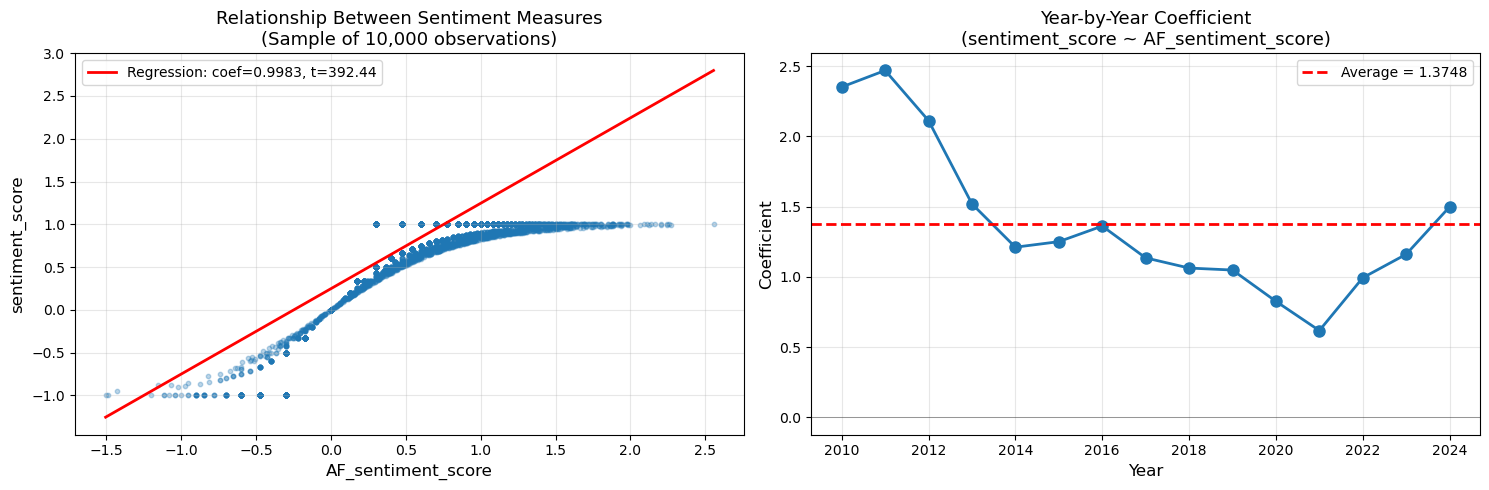


Plot saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_measures_relationship.png


In [28]:
# Visualize the relationship
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scatter plot with regression line (on a sample for visibility)
sample_size = min(10000, len(df_sentiment_compare))
df_sample = df_sentiment_compare.sample(n=sample_size, random_state=42)

axes[0].scatter(df_sample['AF_sentiment_score'], df_sample['sentiment_score'], 
                alpha=0.3, s=10)
axes[0].set_xlabel('AF_sentiment_score', fontsize=12)
axes[0].set_ylabel('sentiment_score', fontsize=12)
axes[0].set_title(f'Relationship Between Sentiment Measures\n(Sample of {sample_size:,} observations)', 
                  fontsize=13)
axes[0].grid(True, alpha=0.3)

# Add regression line
x_range = np.linspace(df_sample['AF_sentiment_score'].min(), 
                      df_sample['AF_sentiment_score'].max(), 100)
y_pred = results_overall.params['const'] + results_overall.params['AF_sentiment_score'] * x_range
axes[0].plot(x_range, y_pred, 'r-', linewidth=2, 
            label=f'Regression: coef={coef_overall:.4f}, t={tstat_overall:.2f}')
axes[0].legend(fontsize=10)

# Plot 2: Coefficient by year
axes[1].plot(df_yearly_results['Year'], df_yearly_results['Coefficient'], 
             marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=avg_coef, color='r', linestyle='--', linewidth=2, 
                label=f'Average = {avg_coef:.4f}')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Coefficient', fontsize=12)
axes[1].set_title('Year-by-Year Coefficient\n(sentiment_score ~ AF_sentiment_score)', 
                  fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
plot_file = os.path.join(results_output_folder, "sentiment_measures_relationship.png")
fig.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {plot_file}")

In [29]:
# Save the year-by-year results to CSV
yearly_results_file = os.path.join(results_output_folder, "sentiment_measures_comparison_yearly.csv")
df_yearly_results.to_csv(yearly_results_file, index=False)
print(f"Year-by-year comparison results saved to: {yearly_results_file}")

# Create a summary table
summary_data = {
    'Analysis': ['Overall (Pooled)', 'Average Across Years'],
    'Coefficient': [coef_overall, avg_coef],
    't-statistic': [tstat_overall, avg_tstat],
    'R-squared': [rsq_overall, avg_rsq],
    'N': [int(results_overall.nobs), int(df_yearly_results['N'].mean())]
}

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY TABLE: sentiment_score ~ AF_sentiment_score")
print("="*80)
print(df_summary.to_string(index=False))

summary_file = os.path.join(results_output_folder, "sentiment_measures_comparison_summary.csv")
df_summary.to_csv(summary_file, index=False)
print(f"\nSummary table saved to: {summary_file}")

Year-by-year comparison results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_measures_comparison_yearly.csv

SUMMARY TABLE: sentiment_score ~ AF_sentiment_score
            Analysis  Coefficient  t-statistic  R-squared       N
    Overall (Pooled)     0.998285   392.435148   0.480336 3032691
Average Across Years     1.374771   106.633842   0.579250  202179

Summary table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_measures_comparison_summary.csv


## 7. Binned Scatter Plot: AF Sentiment vs Abnormal Returns

Let's visualize the relationship between Antweiler-Frank sentiment score and abnormal returns using binned scatter plots for different horizons.

Creating binned scatter plots for models: ['FF3', 'FF5', 'FF6', 'capm', 'dgtw']
Horizons: [1, 5, 21]
Plotting 15 subplots...
Plotting 15 subplots...


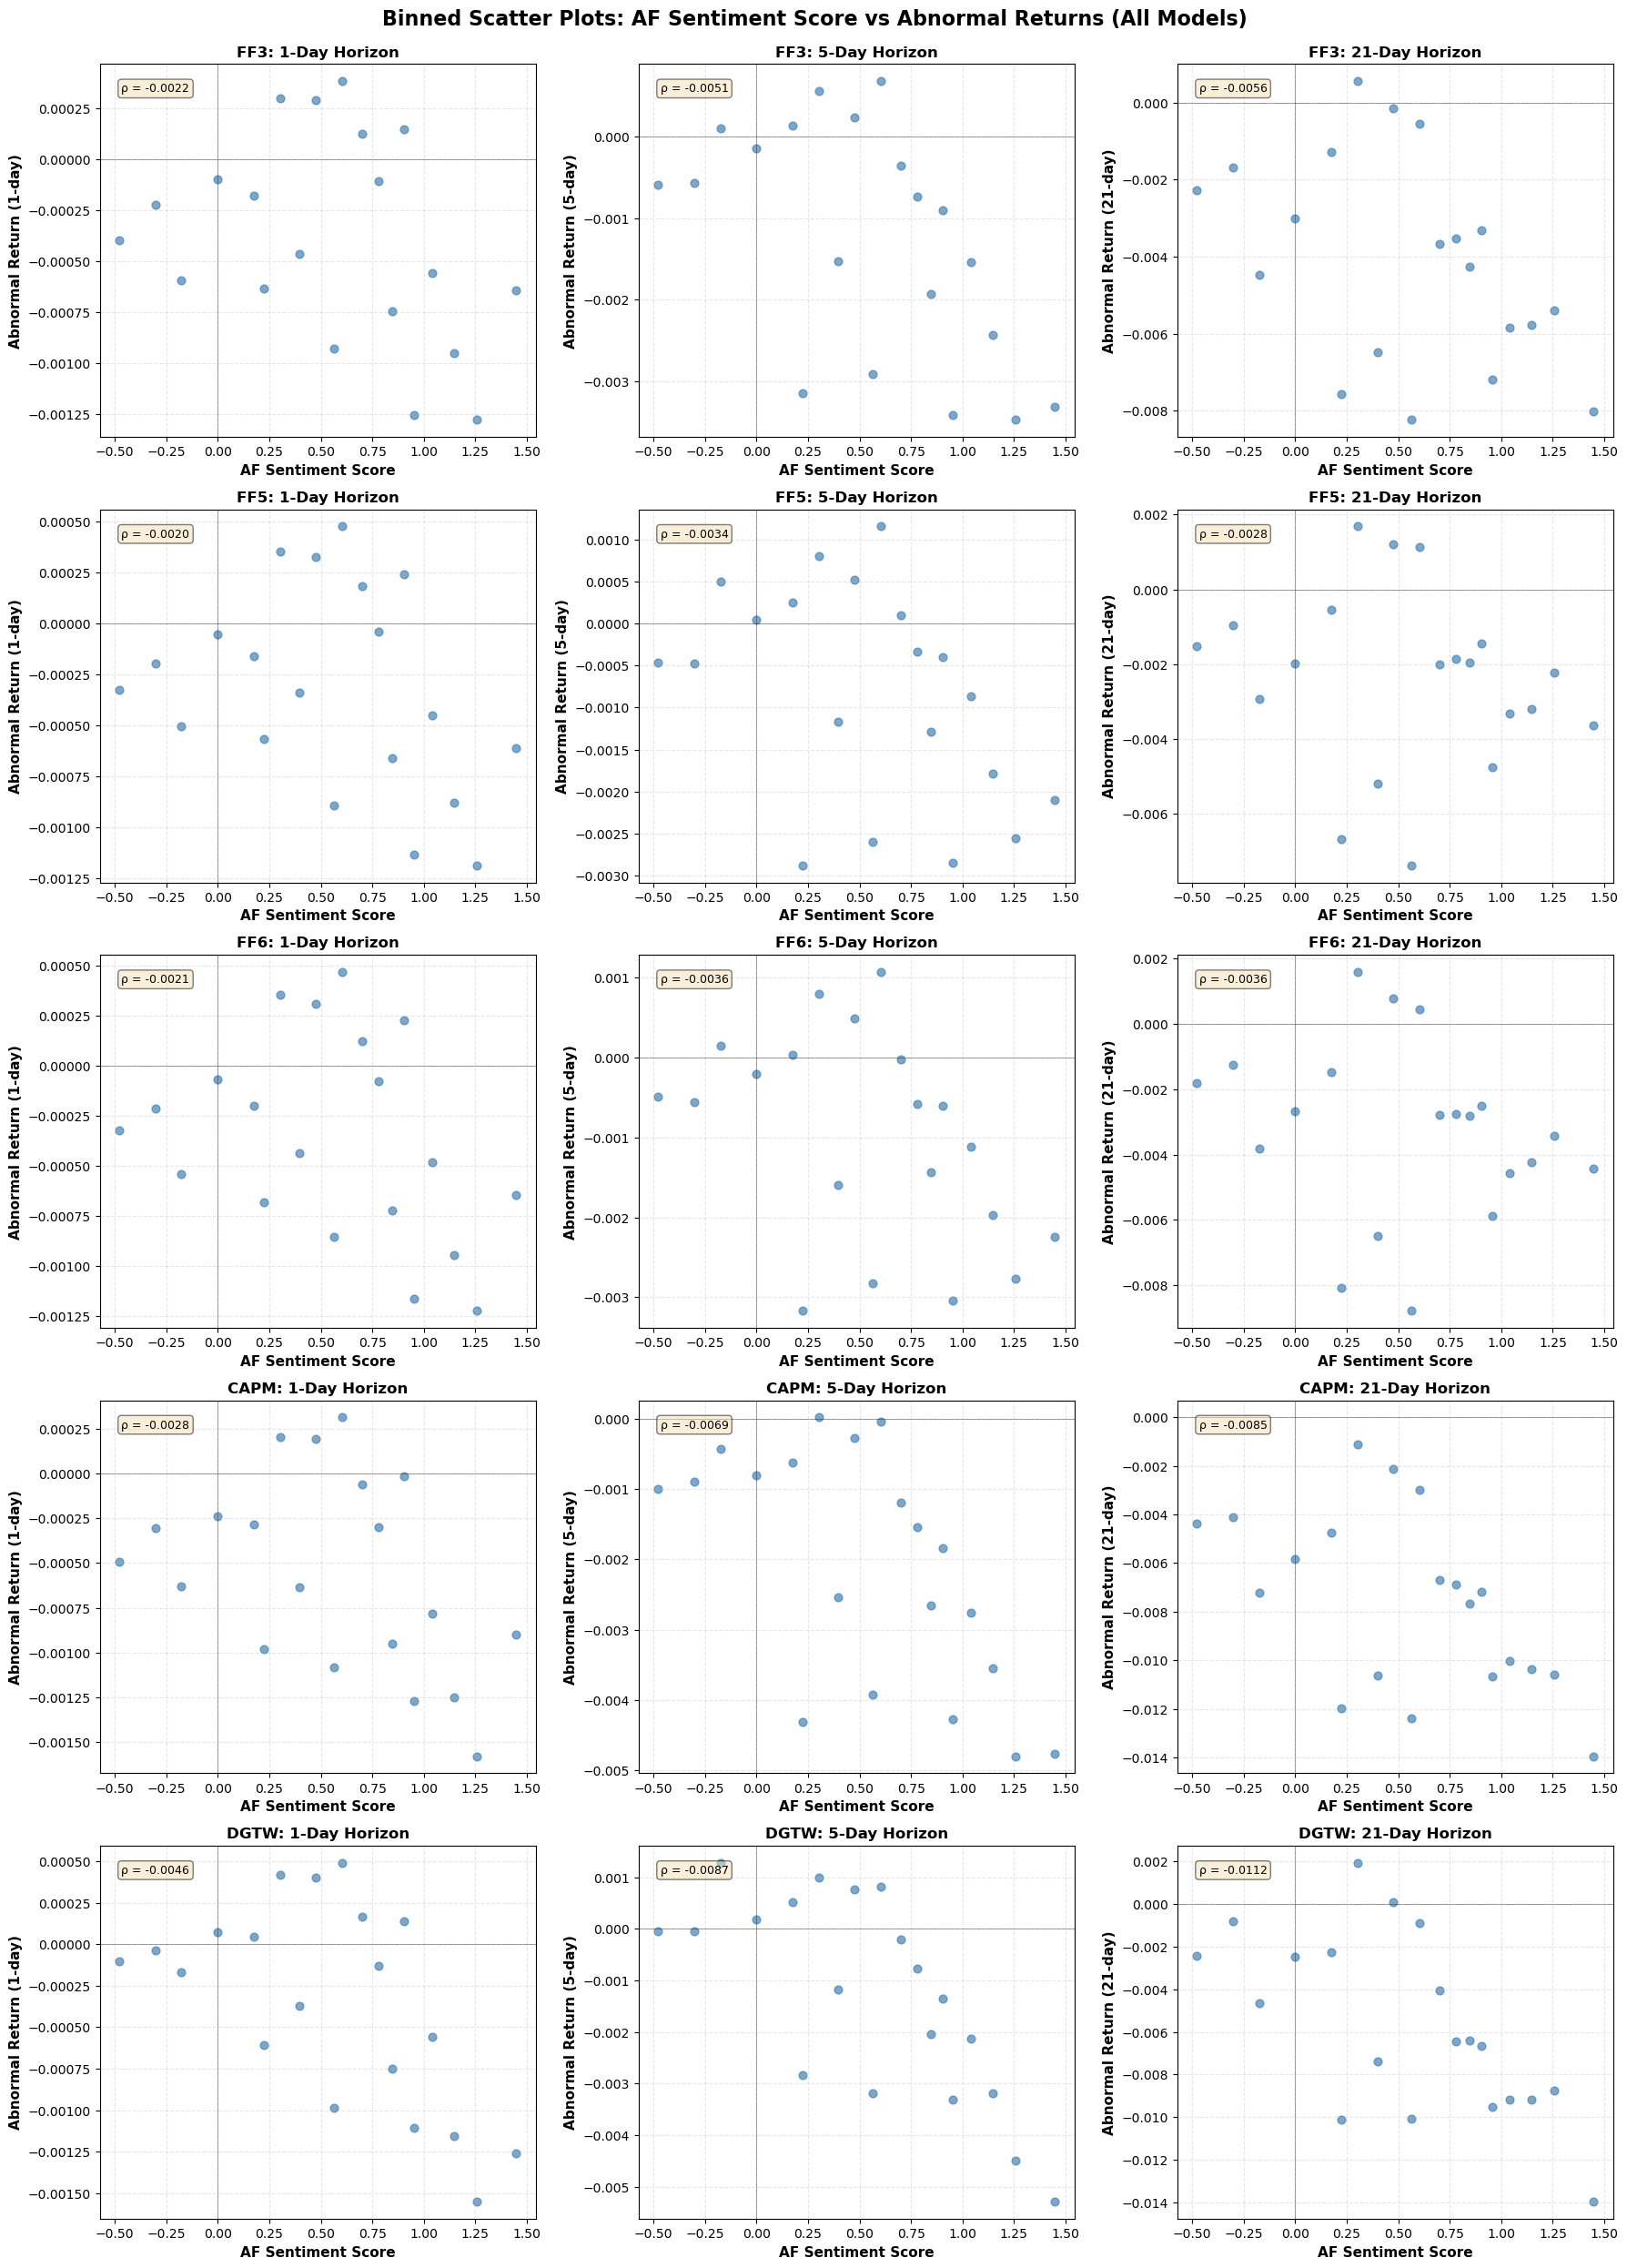

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select horizons and get all models
selected_horizons = [1, 5, 21]  # 1-day, 1-week, 1-month
all_models = sorted(set([m[0] for m in models_horizons]))  # All unique models

print(f"Creating binned scatter plots for models: {all_models}")
print(f"Horizons: {selected_horizons}")

# Create subplots: rows = models, columns = horizons
n_models = len(all_models)
n_horizons = len(selected_horizons)
fig, axes = plt.subplots(n_models, n_horizons, figsize=(6*n_horizons, 5*n_models))

# If only one model, make axes 2D for consistent indexing
if n_models == 1:
    axes = axes.reshape(1, -1)

# Collect all AR columns needed
ar_cols_needed = [f'ar_{model}_{h}' for model in all_models for h in selected_horizons]
df_plot = df_reg[['AF_sentiment_score'] + ar_cols_needed].dropna()

print(f"Plotting {n_models * n_horizons} subplots...")

# Create plots
for model_idx, model in enumerate(all_models):
    for horizon_idx, horizon in enumerate(selected_horizons):
        ar_col = f'ar_{model}_{horizon}'
        ax = axes[model_idx, horizon_idx]
        
        # Create binned scatter plot
        # fit_reg=False and ci=None for speed (no regression line, no confidence intervals)
        sns.regplot(
            data=df_plot,
            x='AF_sentiment_score',
            y=ar_col,
            x_bins=50,  # Number of bins
            fit_reg=False,  # No regression line
            ci=None,  # No confidence intervals
            scatter_kws={'alpha': 0.7, 's': 40, 'color': 'steelblue'},
            ax=ax
        )
        
        # Formatting
        ax.set_xlabel('AF Sentiment Score', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Abnormal Return ({horizon}-day)', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()}: {horizon}-Day Horizon', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        
        # Add correlation in corner
        corr = df_plot['AF_sentiment_score'].corr(df_plot[ar_col])
        ax.text(0.05, 0.95, f'ρ = {corr:.4f}', 
                transform=ax.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Binned Scatter Plots: AF Sentiment Score vs Abnormal Returns (All Models)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Creating binned scatter plots for sentiment_score
Models: ['FF3', 'FF5', 'FF6', 'capm', 'dgtw']
Horizons: [1, 5, 21]
Plotting 15 subplots...


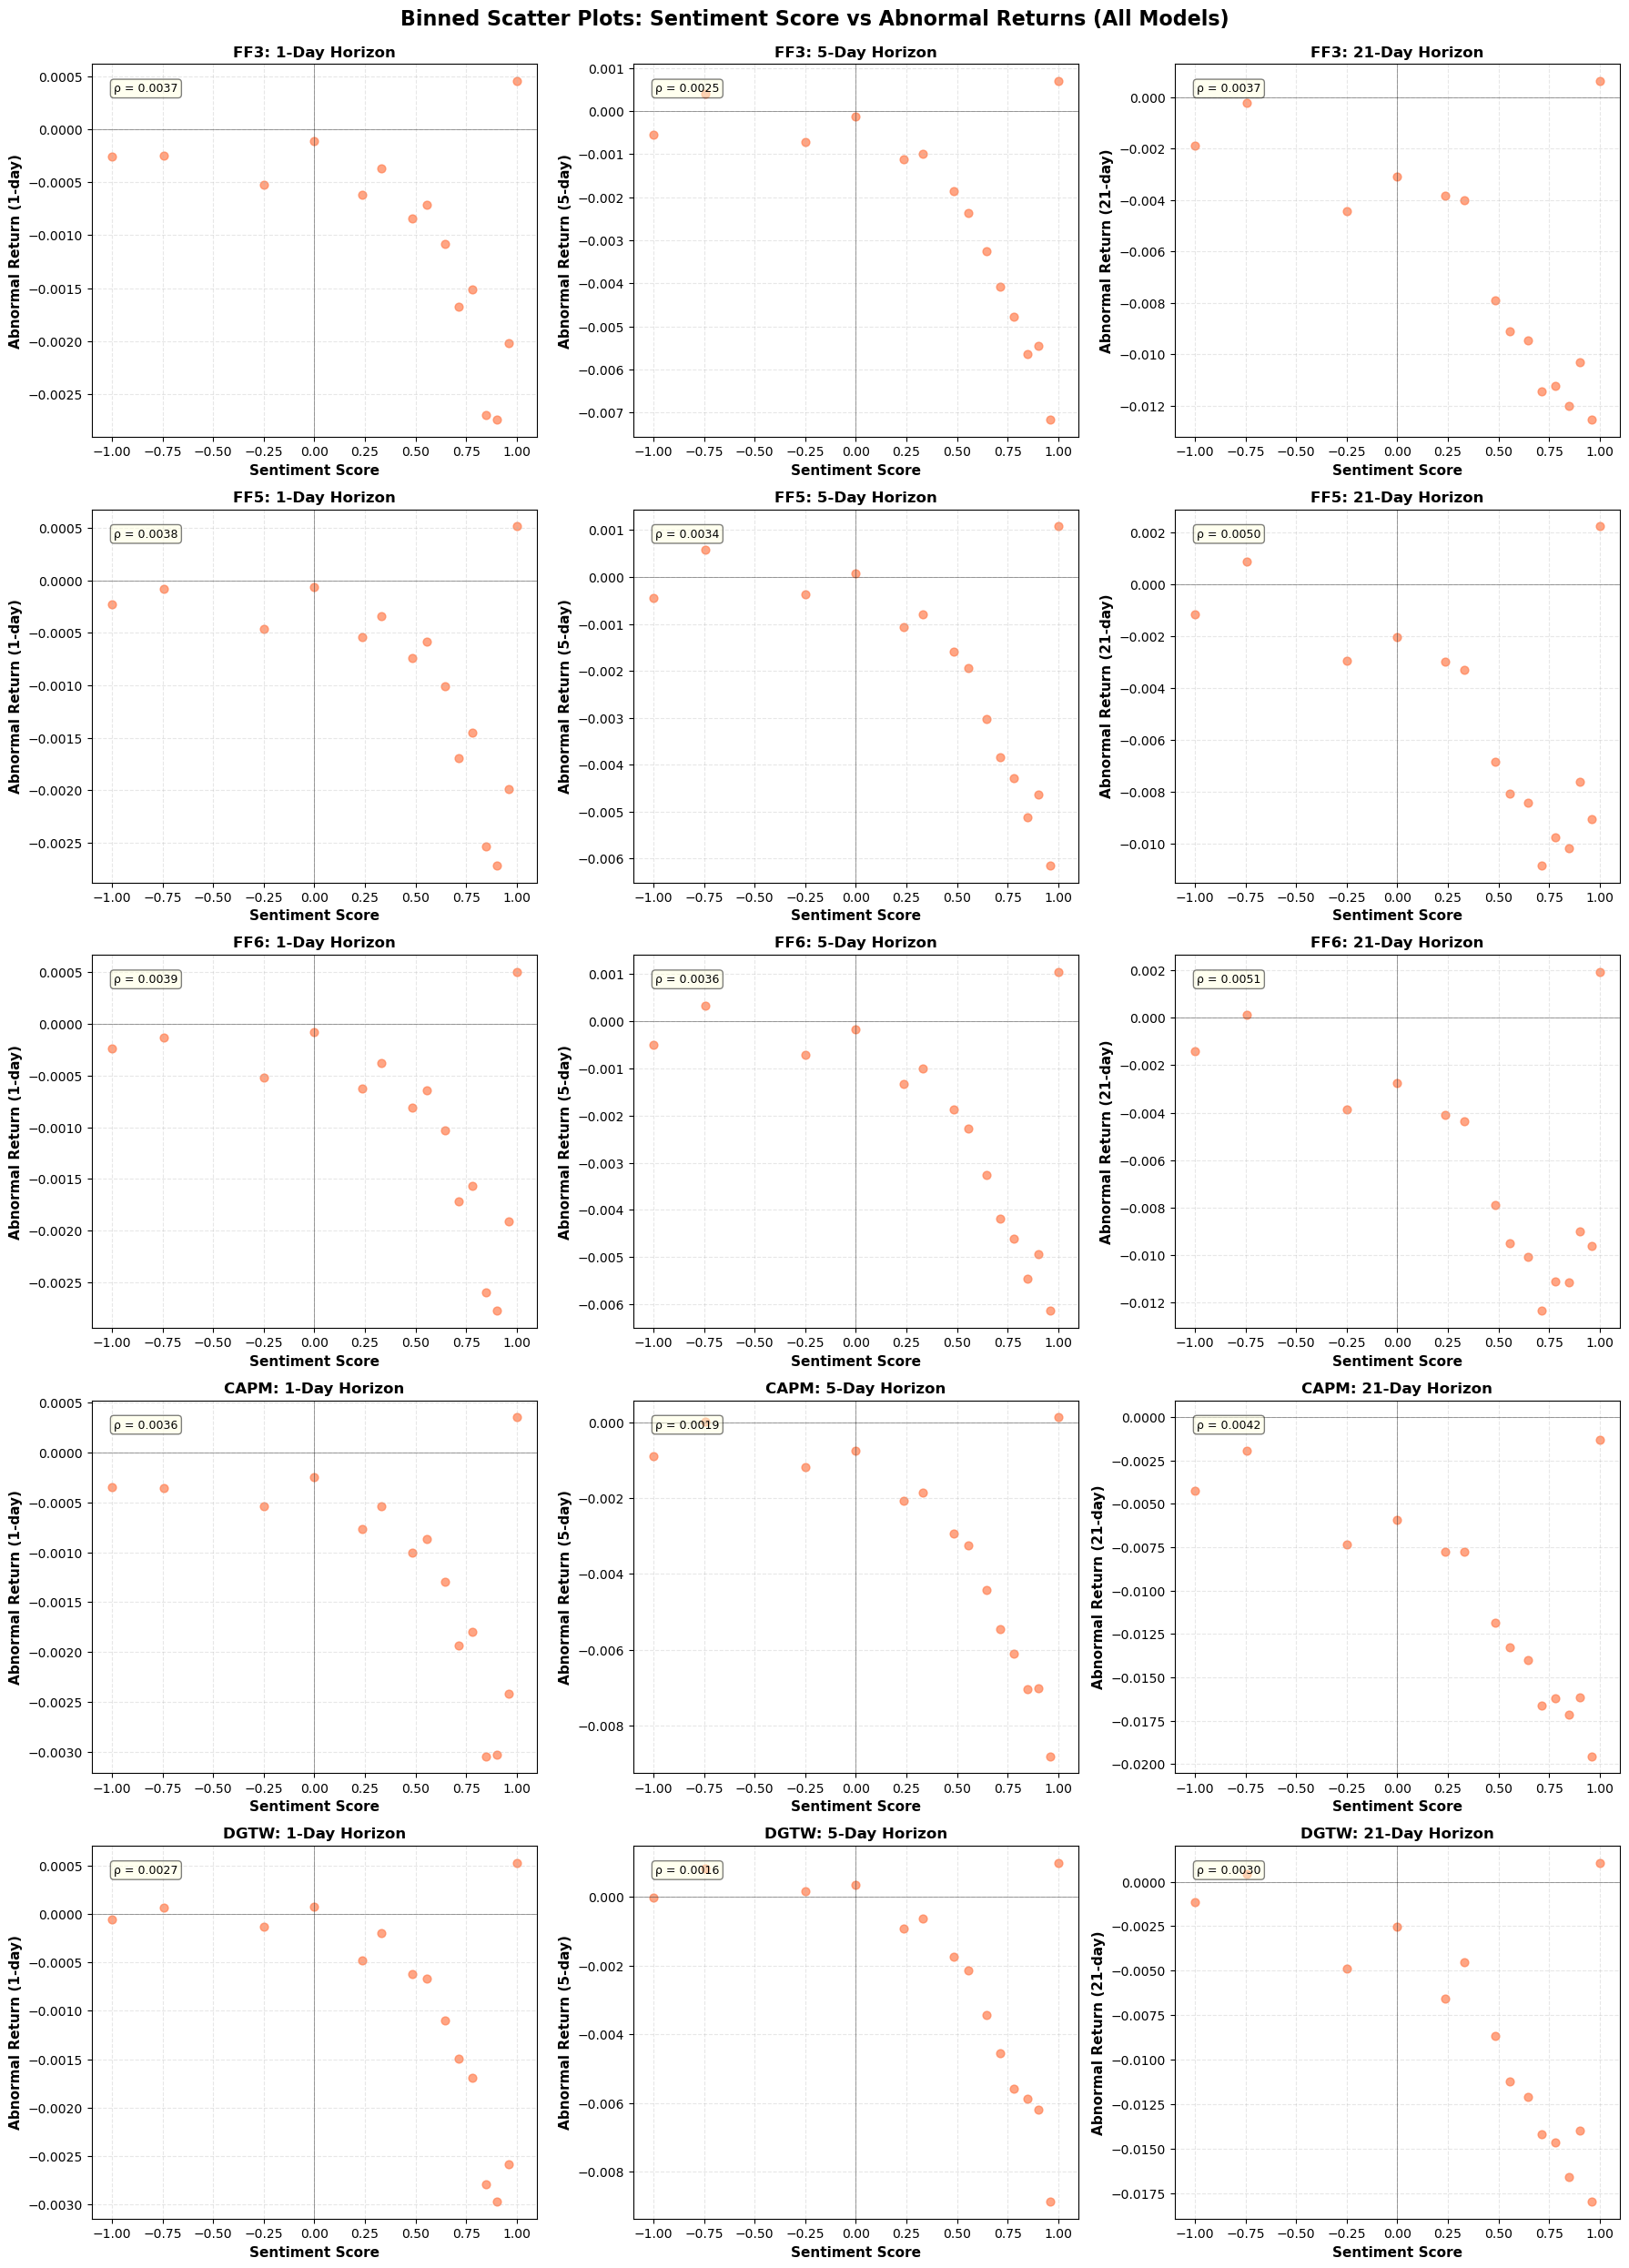

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select horizons and get all models
selected_horizons = [1, 5, 21]  # 1-day, 1-week, 1-month
all_models = sorted(set([m[0] for m in models_horizons]))  # All unique models

print(f"Creating binned scatter plots for sentiment_score")
print(f"Models: {all_models}")
print(f"Horizons: {selected_horizons}")

# Create subplots: rows = models, columns = horizons
n_models = len(all_models)
n_horizons = len(selected_horizons)
fig, axes = plt.subplots(n_models, n_horizons, figsize=(6*n_horizons, 5*n_models))

# If only one model, make axes 2D for consistent indexing
if n_models == 1:
    axes = axes.reshape(1, -1)

# Collect all AR columns needed
ar_cols_needed = [f'ar_{model}_{h}' for model in all_models for h in selected_horizons]
df_plot = df_reg[['sentiment_score'] + ar_cols_needed].dropna()

print(f"Plotting {n_models * n_horizons} subplots...")

# Create plots
for model_idx, model in enumerate(all_models):
    for horizon_idx, horizon in enumerate(selected_horizons):
        ar_col = f'ar_{model}_{horizon}'
        ax = axes[model_idx, horizon_idx]
        
        # Create binned scatter plot
        # fit_reg=False and ci=None for speed (no regression line, no confidence intervals)
        sns.regplot(
            data=df_plot,
            x='sentiment_score',
            y=ar_col,
            x_bins=50,  # Number of bins
            fit_reg=False,  # No regression line
            ci=None,  # No confidence intervals
            scatter_kws={'alpha': 0.7, 's': 40, 'color': 'coral'},
            ax=ax
        )
        
        # Formatting
        ax.set_xlabel('Sentiment Score', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Abnormal Return ({horizon}-day)', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()}: {horizon}-Day Horizon', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        
        # Add correlation in corner
        corr = df_plot['sentiment_score'].corr(df_plot[ar_col])
        ax.text(0.05, 0.95, f'ρ = {corr:.4f}', 
                transform=ax.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.suptitle('Binned Scatter Plots: Sentiment Score vs Abnormal Returns (All Models)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 8. Investigating Extreme Sentiment Scores

Let's examine ticker-date pairs where the sentiment score equals 1 (all tweets are bullish).

In [40]:
# Isolate data where sentiment_score equals 1 (all tweets bullish, no bearish tweets)
df_perfect_bullish = df_reg[df_reg['sentiment_score'] == 1.0].copy()

print(f"Data where sentiment_score = 1.0 (All Bullish)")
print("="*80)
print(f"\nTotal observations: {len(df_perfect_bullish):,}")
print(f"Percentage of total data: {len(df_perfect_bullish) / len(df_reg) * 100:.2f}%")

print(f"\n{'='*80}")
print("Distribution of Number of Tweets:")
print("="*80)
print(df_perfect_bullish['n_tweets'].describe())

print(f"\n{'='*80}")
print("Number of tweets breakdown:")
print("="*80)
tweet_count_dist = df_perfect_bullish['n_tweets'].value_counts().sort_index()
print(tweet_count_dist.head(20))

print(f"\n{'='*80}")
print("Top 20 Most Frequent Stocks with Perfect Bullish Sentiment:")
print("="*80)
top_stocks_bullish = df_perfect_bullish['symbol'].value_counts().head(20)
print(top_stocks_bullish)

print(f"\n{'='*80}")
print("Sample of Perfect Bullish Data:")
print("="*80)
# Show a sample with key columns
sample_cols = ['symbol', 'date', 'n_tweets', 'n_bullish', 'n_bearish', 
               'sentiment_score', 'AF_sentiment_score']
# Add first AR column if available
ar_cols_sample = [col for col in df_perfect_bullish.columns if col.startswith('ar_')]
if ar_cols_sample:
    sample_cols.extend(ar_cols_sample[:2])  # Add first 2 AR columns

print(df_perfect_bullish[sample_cols].head(20))

Data where sentiment_score = 1.0 (All Bullish)

Total observations: 1,948,608
Percentage of total data: 64.25%

Distribution of Number of Tweets:
count    1.948608e+06
mean     3.922585e+00
std      1.001915e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      2.150000e+03
Name: n_tweets, dtype: float64

Number of tweets breakdown:
n_tweets
1     1007411
2      329981
3      160723
4       97867
5       64879
6       46824
7       35073
8       27389
9       21900
10      17828
11      14496
12      12511
13      10652
14       9076
15       7868
16       6990
17       6075
18       5482
19       4781
20       4349
Name: count, dtype: int64

Top 20 Most Frequent Stocks with Perfect Bullish Sentiment:
symbol
CPRX    1772
ATHX    1754
CLDX    1598
SWIR    1577
GERN    1573
SIRI    1572
ARWR    1571
TGTX    1571
DRRX    1558
AGEN    1540
MA      1533
ACAD    1466
V       1446
EXEL    1443
MO      1428
EXAS    1414
ABBV    1397
ICPT    1389
S

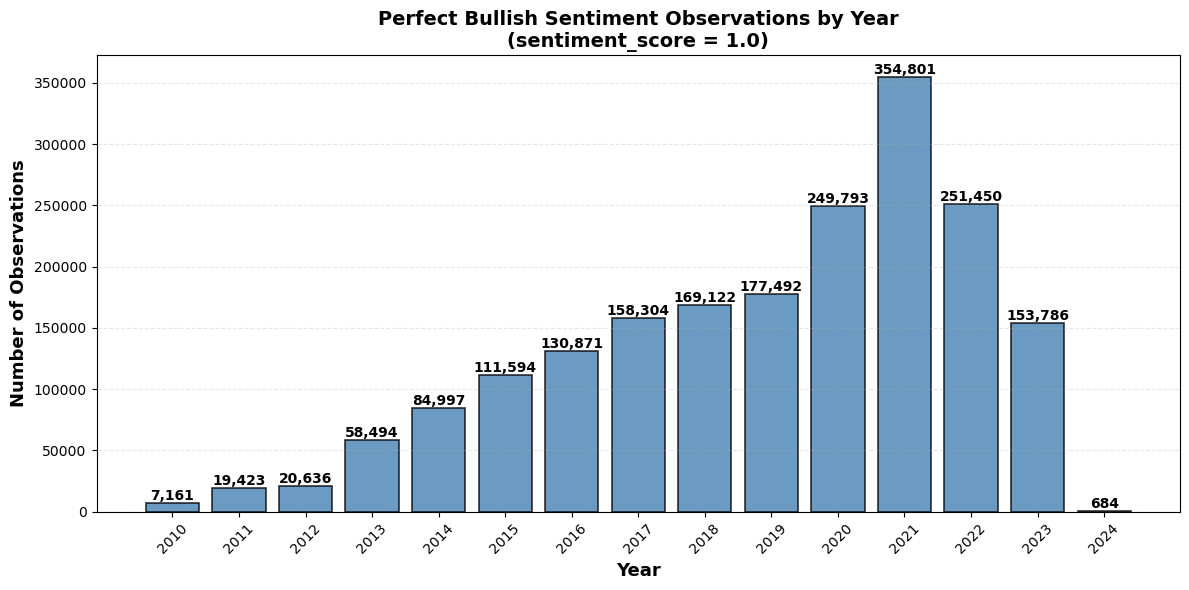


Perfect Bullish Sentiment Observations by Year:
 year  count
 2010   7161
 2011  19423
 2012  20636
 2013  58494
 2014  84997
 2015 111594
 2016 130871
 2017 158304
 2018 169122
 2019 177492
 2020 249793
 2021 354801
 2022 251450
 2023 153786
 2024    684

Total: 1,948,608 observations


In [41]:
# Bar chart: Number of perfect bullish observations by year
import matplotlib.pyplot as plt

# Count observations by year
yearly_counts = df_perfect_bullish.groupby('year').size().reset_index(name='count')

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(yearly_counts['year'], yearly_counts['count'], 
       color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.2)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Observations', fontsize=13, fontweight='bold')
ax.set_title('Perfect Bullish Sentiment Observations by Year\n(sentiment_score = 1.0)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on top of bars
for i, row in yearly_counts.iterrows():
    ax.text(row['year'], row['count'], f"{row['count']:,}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Set x-axis to show all years
ax.set_xticks(yearly_counts['year'])
ax.set_xticklabels(yearly_counts['year'], rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Perfect Bullish Sentiment Observations by Year:")
print("="*80)
print(yearly_counts.to_string(index=False))
print(f"\nTotal: {yearly_counts['count'].sum():,} observations")

## 9. Pre-2021 Regressions: Sentiment  Abnormal Returns

We repeat the baseline regressions restricting the data to years before 2021 (i.e., year < 2021), for both sentiment measures, with standard errors clustered by ticker-month. We'll produce tabulated results comparable to earlier tables.

In [42]:
# Create pre-2021 filtered dataset and ensure required columns exist
import pandas as pd

# Ensure 'year' column exists
if 'year' not in df_reg.columns:
    df_reg['year'] = df_reg['date'].dt.year

# Ensure ticker-month clustering variable exists
if 'cluster_var' not in df_reg.columns:
    df_reg['year_month'] = df_reg['date'].dt.to_period('M').astype(str)
    df_reg['cluster_var'] = df_reg['symbol'] + '_' + df_reg['year_month']

# Filter to years before 2021
df_reg_pre21 = df_reg[df_reg['year'] < 2021].copy()

print("Pre-2021 filter applied (year < 2021)")
print(f"Total observations (pre-2021): {len(df_reg_pre21):,}")
print(f"Unique tickers: {df_reg_pre21['symbol'].nunique():,}")
print(f"Years covered: {sorted(df_reg_pre21['year'].unique())[:3]} ... {sorted(df_reg_pre21['year'].unique())[-3:]}")

# Sanity check for available AR columns
ar_columns_pre21 = [col for col in df_reg_pre21.columns if col.startswith('ar_')]
print(f"AR columns available: {len(ar_columns_pre21)}")

Pre-2021 filter applied (year < 2021)
Total observations (pre-2021): 1,827,148
Unique tickers: 6,276
Years covered: [2010, 2011, 2012] ... [2018, 2019, 2020]
AR columns available: 35


In [43]:
# Run pre-2021 regressions for sentiment_score (ticker-month clustering)
from tqdm import tqdm
import numpy as np

print("="*60)
print("Running pre-2021 regressions for sentiment_score...")
print("="*60)

results_sentiment_pre21 = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions (pre-2021)"):
    y = df_reg_pre21[ar_col]
    X = df_reg_pre21[['sentiment_score']]
    clusters = df_reg_pre21['cluster_var']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_sentiment_pre21.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_sentiment_pre21 = pd.DataFrame(results_sentiment_pre21)

print("\nCompleted pre-2021 sentiment_score regressions")

Running pre-2021 regressions for sentiment_score...


Running regressions (pre-2021): 100%|██████████| 35/35 [01:04<00:00,  1.83s/it]


Completed pre-2021 sentiment_score regressions


In [44]:
# Run pre-2021 regressions for AF_sentiment_score (ticker-month clustering)
print("="*60)
print("Running pre-2021 regressions for AF_sentiment_score...")
print("="*60)

results_AF_pre21 = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions (pre-2021)"):
    y = df_reg_pre21[ar_col]
    X = df_reg_pre21[['AF_sentiment_score']]
    clusters = df_reg_pre21['cluster_var']
    
    coef, tstat, nobs = run_clustered_regression(y, X, clusters)
    
    results_AF_pre21.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_AF_pre21 = pd.DataFrame(results_AF_pre21)

print("\nCompleted pre-2021 AF_sentiment_score regressions")

Running pre-2021 regressions for AF_sentiment_score...


Running regressions (pre-2021): 100%|██████████| 35/35 [01:03<00:00,  1.81s/it]


Completed pre-2021 AF_sentiment_score regressions


In [45]:
# Tabulate pre-2021 results: sentiment_score
print("="*80)
print("TABLE 1 (Pre-2021): Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

models = sorted(df_results_sentiment_pre21['Model'].unique())
horizons = sorted(df_results_sentiment_pre21['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table = df_results_sentiment_pre21.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table = df_results_sentiment_pre21.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)
for model in models:
    row_data = [model]
    for horizon in horizons:
        coef = df_results_sentiment_pre21[(df_results_sentiment_pre21['Model'] == model) & (df_results_sentiment_pre21['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_sentiment_pre21[(df_results_sentiment_pre21['Model'] == model) & (df_results_sentiment_pre21['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

# Tabulate pre-2021 results: AF_sentiment_score
print("\n" + "="*80)
print("TABLE 2 (Pre-2021): Antweiler-Frank Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

models_af = sorted(df_results_AF_pre21['Model'].unique())
horizons_af = sorted(df_results_AF_pre21['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table_af = df_results_AF_pre21.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table_af.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table_af = df_results_AF_pre21.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table_af.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)
for model in models_af:
    row_data = [model]
    for horizon in horizons_af:
        coef = df_results_AF_pre21[(df_results_AF_pre21['Model'] == model) & (df_results_AF_pre21['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_AF_pre21[(df_results_AF_pre21['Model'] == model) & (df_results_AF_pre21['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 1 (Pre-2021): Sentiment Score → Abnormal Returns
Standard errors clustered by ticker and month

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3      0.000319  0.000439  0.000554  0.000912  0.001829  0.001829  0.001829
FF5      0.000330  0.000489  0.000626  0.001023  0.001960  0.001960  0.001960
FF6      0.000345  0.000538  0.000687  0.001108  0.001978  0.001978  0.001978
capm     0.000321  0.000392  0.000528  0.001017  0.002335  0.002335  0.002335
dgtw     0.000252  0.000319  0.000431  0.000621  0.001669  0.004872  0.006270


t-statistics:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3 

In [46]:
# Save pre-2021 regression results to CSV (optional, for record-keeping)
import os

os.makedirs(results_output_folder, exist_ok=True)

# Save raw results
sentiment_pre21_file = os.path.join(results_output_folder, "sentiment_score_results_pre2021.csv")
df_results_sentiment_pre21.to_csv(sentiment_pre21_file, index=False)
print(f"Sentiment score (pre-2021) results saved to: {sentiment_pre21_file}")

af_pre21_file = os.path.join(results_output_folder, "AF_sentiment_score_results_pre2021.csv")
df_results_AF_pre21.to_csv(af_pre21_file, index=False)
print(f"AF sentiment score (pre-2021) results saved to: {af_pre21_file}")

# Create publication-style combined CSVs
# Table 1 (pre-2021): sentiment_score
pre21_table1_pivot = df_results_sentiment_pre21.pivot(index='Model', columns='Horizon', values='Coefficient')
pre21_table1_pivot_t = df_results_sentiment_pre21.pivot(index='Model', columns='Horizon', values='t-stat')

pre21_table1_combined = pd.DataFrame(index=pre21_table1_pivot.index)
for col in pre21_table1_pivot.columns:
    pre21_table1_combined[f'H{col}'] = pre21_table1_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    pre21_table1_combined[f'H{col}_tstat'] = pre21_table1_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

pre21_table1_file = os.path.join(results_output_folder, "table1_sentiment_score_pre2021.csv")
pre21_table1_combined.to_csv(pre21_table1_file)
print(f"Table 1 (pre-2021, sentiment_score) saved to: {pre21_table1_file}")

# Table 2 (pre-2021): AF_sentiment_score
pre21_table2_pivot = df_results_AF_pre21.pivot(index='Model', columns='Horizon', values='Coefficient')
pre21_table2_pivot_t = df_results_AF_pre21.pivot(index='Model', columns='Horizon', values='t-stat')

pre21_table2_combined = pd.DataFrame(index=pre21_table2_pivot.index)
for col in pre21_table2_pivot.columns:
    pre21_table2_combined[f'H{col}'] = pre21_table2_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    pre21_table2_combined[f'H{col}_tstat'] = pre21_table2_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

pre21_table2_file = os.path.join(results_output_folder, "table2_AF_sentiment_score_pre2021.csv")
pre21_table2_combined.to_csv(pre21_table2_file)
print(f"Table 2 (pre-2021, AF_sentiment_score) saved to: {pre21_table2_file}")

Sentiment score (pre-2021) results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_results_pre2021.csv
AF sentiment score (pre-2021) results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\AF_sentiment_score_results_pre2021.csv
Table 1 (pre-2021, sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table1_sentiment_score_pre2021.csv
Table 2 (pre-2021, AF_sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table2_AF_sentiment_score_pre2021.csv


## 10. Regressions Excluding Sentiment = 1.0 (Full Sample)

We repeat the baseline full-sample regressions after dropping all ticker–date observations with `sentiment_score == 1.0` (all tweets bullish). Standard errors remain clustered by ticker–month, and we tabulate results for both sentiment measures.

In [47]:
# Create full-sample dataset excluding sentiment_score == 1.0 and report summary
import numpy as np

n_total = len(df_reg)
df_reg_excl1 = df_reg[df_reg['sentiment_score'] != 1.0].copy()
n_kept = len(df_reg_excl1)

print("Excluding observations with sentiment_score == 1.0 (full sample)")
print("="*80)
print(f"Total observations (original): {n_total:,}")
print(f"Observations kept:            {n_kept:,}")
print(f"Observations dropped:         {n_total - n_kept:,}  ({(n_total - n_kept)/max(n_total,1)*100:.2f}%)")
print(f"Unique tickers kept:          {df_reg_excl1['symbol'].nunique():,}")
print(f"Years covered:                {df_reg_excl1['date'].dt.year.min()} – {df_reg_excl1['date'].dt.year.max()}")

# Sanity: cluster_var should already exist from earlier sections; recreate if missing
if 'cluster_var' not in df_reg_excl1.columns:
    df_reg_excl1['year_month'] = df_reg_excl1['date'].dt.to_period('M').astype(str)
    df_reg_excl1['cluster_var'] = df_reg_excl1['symbol'] + '_' + df_reg_excl1['year_month']

# Confirm AR columns present
ar_columns_excl1 = [col for col in df_reg_excl1.columns if col.startswith('ar_')]
print(f"AR columns available: {len(ar_columns_excl1)}")

Excluding observations with sentiment_score == 1.0 (full sample)
Total observations (original): 3,032,691
Observations kept:            1,084,083
Observations dropped:         1,948,608  (64.25%)
Unique tickers kept:          7,451
Years covered:                2010 – 2024
AR columns available: 35


In [48]:
# Regressions (full sample excl. sentiment==1.0): sentiment_score
print("="*60)
print("Running full-sample (exclude sentiment=1.0) regressions for sentiment_score...")
print("="*60)

results_sentiment_excl1 = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions (excl=1.0)"):
    y = df_reg_excl1[ar_col]
    X = df_reg_excl1[['sentiment_score']]
    clusters = df_reg_excl1['cluster_var']

    coef, tstat, nobs = run_clustered_regression(y, X, clusters)

    results_sentiment_excl1.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_sentiment_excl1 = pd.DataFrame(results_sentiment_excl1)

print("\nCompleted full-sample regressions (exclude sentiment=1.0) for sentiment_score")

Running full-sample (exclude sentiment=1.0) regressions for sentiment_score...


Running regressions (excl=1.0): 100%|██████████| 35/35 [00:41<00:00,  1.18s/it]


Completed full-sample regressions (exclude sentiment=1.0) for sentiment_score


In [49]:
# Regressions (full sample excl. sentiment==1.0): AF_sentiment_score
print("="*60)
print("Running full-sample (exclude sentiment=1.0) regressions for AF_sentiment_score...")
print("="*60)

results_AF_excl1 = []

for model, horizon, ar_col in tqdm(models_horizons, desc="Running regressions (excl=1.0)"):
    y = df_reg_excl1[ar_col]
    X = df_reg_excl1[['AF_sentiment_score']]
    clusters = df_reg_excl1['cluster_var']

    coef, tstat, nobs = run_clustered_regression(y, X, clusters)

    results_AF_excl1.append({
        'Model': model,
        'Horizon': horizon,
        'Coefficient': coef,
        't-stat': tstat,
        'N': nobs
    })

df_results_AF_excl1 = pd.DataFrame(results_AF_excl1)

print("\nCompleted full-sample regressions (exclude sentiment=1.0) for AF_sentiment_score")

Running full-sample (exclude sentiment=1.0) regressions for AF_sentiment_score...


Running regressions (excl=1.0): 100%|██████████| 35/35 [00:39<00:00,  1.12s/it]


Completed full-sample regressions (exclude sentiment=1.0) for AF_sentiment_score


In [50]:
# Tabulate full-sample (exclude sentiment=1.0) results: sentiment_score
print("="*80)
print("TABLE 1 (Exclude Sentiment=1.0): Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

models_ex = sorted(df_results_sentiment_excl1['Model'].unique())
horizons_ex = sorted(df_results_sentiment_excl1['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table_ex = df_results_sentiment_excl1.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table_ex.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table_ex = df_results_sentiment_excl1.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table_ex.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)
for model in models_ex:
    row_data = [model]
    for horizon in horizons_ex:
        coef = df_results_sentiment_excl1[(df_results_sentiment_excl1['Model'] == model) & (df_results_sentiment_excl1['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_sentiment_excl1[(df_results_sentiment_excl1['Model'] == model) & (df_results_sentiment_excl1['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

# Tabulate full-sample (exclude sentiment=1.0) results: AF_sentiment_score
print("\n" + "="*80)
print("TABLE 2 (Exclude Sentiment=1.0): Antweiler-Frank Sentiment Score → Abnormal Returns")
print("="*80)
print("Standard errors clustered by ticker and month")
print("="*80)

models_af_ex = sorted(df_results_AF_excl1['Model'].unique())
horizons_af_ex = sorted(df_results_AF_excl1['Horizon'].unique())

print("\nCoefficients:")
print("-" * 80)
coef_table_af_ex = df_results_AF_excl1.pivot(index='Model', columns='Horizon', values='Coefficient')
print(coef_table_af_ex.to_string())

print("\n\nt-statistics:")
print("-" * 80)
tstat_table_af_ex = df_results_AF_excl1.pivot(index='Model', columns='Horizon', values='t-stat')
print(tstat_table_af_ex.to_string())

print("\n\nFormatted table (Coefficient with t-stat in parentheses):")
print("-" * 80)
for model in models_af_ex:
    row_data = [model]
    for horizon in horizons_af_ex:
        coef = df_results_AF_excl1[(df_results_AF_excl1['Model'] == model) & (df_results_AF_excl1['Horizon'] == horizon)]['Coefficient'].values
        tstat = df_results_AF_excl1[(df_results_AF_excl1['Model'] == model) & (df_results_AF_excl1['Horizon'] == horizon)]['t-stat'].values
        if len(coef) > 0 and not np.isnan(coef[0]):
            row_data.append(f"{coef[0]:.4f}\n({tstat[0]:.2f})")
        else:
            row_data.append("N/A")
    print(f"{row_data[0]:10s}", end="")
    for val in row_data[1:]:
        print(f" {val:>12s}", end="")
    print()

print("\nNote: t-statistics in parentheses")

TABLE 1 (Exclude Sentiment=1.0): Sentiment Score → Abnormal Returns
Standard errors clustered by ticker and month

Coefficients:
--------------------------------------------------------------------------------
Horizon        1         3         5         10        21        42        63
Model                                                                        
FF3     -0.000858 -0.001854 -0.002411 -0.003577 -0.005659 -0.005659 -0.005659
FF5     -0.000844 -0.001729 -0.002195 -0.003217 -0.005156 -0.005156 -0.005156
FF6     -0.000858 -0.001764 -0.002287 -0.003374 -0.005600 -0.005600 -0.005600
capm    -0.000950 -0.002167 -0.002892 -0.004398 -0.006999 -0.006999 -0.006999
dgtw    -0.001074 -0.002257 -0.002949 -0.004571 -0.007340 -0.011047 -0.013936


t-statistics:
--------------------------------------------------------------------------------
Horizon         1          3          5         10        21        42        63
Model                                                             

In [51]:
# Save full-sample (exclude sentiment=1.0) regression results to CSV
os.makedirs(results_output_folder, exist_ok=True)

sentiment_excl1_file = os.path.join(results_output_folder, "sentiment_score_results_exclude_sentiment1.csv")
df_results_sentiment_excl1.to_csv(sentiment_excl1_file, index=False)
print(f"Sentiment score (exclude sentiment=1.0) results saved to: {sentiment_excl1_file}")

af_excl1_file = os.path.join(results_output_folder, "AF_sentiment_score_results_exclude_sentiment1.csv")
df_results_AF_excl1.to_csv(af_excl1_file, index=False)
print(f"AF sentiment score (exclude sentiment=1.0) results saved to: {af_excl1_file}")

# Combined "publication-style" CSVs
excl1_table1_pivot = df_results_sentiment_excl1.pivot(index='Model', columns='Horizon', values='Coefficient')
excl1_table1_pivot_t = df_results_sentiment_excl1.pivot(index='Model', columns='Horizon', values='t-stat')

excl1_table1_combined = pd.DataFrame(index=excl1_table1_pivot.index)
for col in excl1_table1_pivot.columns:
    excl1_table1_combined[f'H{col}'] = excl1_table1_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    excl1_table1_combined[f'H{col}_tstat'] = excl1_table1_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

excl1_table1_file = os.path.join(results_output_folder, "table1_sentiment_score_exclude_sentiment1.csv")
excl1_table1_combined.to_csv(excl1_table1_file)
print(f"Table 1 (exclude sentiment=1.0, sentiment_score) saved to: {excl1_table1_file}")

excl1_table2_pivot = df_results_AF_excl1.pivot(index='Model', columns='Horizon', values='Coefficient')
excl1_table2_pivot_t = df_results_AF_excl1.pivot(index='Model', columns='Horizon', values='t-stat')

excl1_table2_combined = pd.DataFrame(index=excl1_table2_pivot.index)
for col in excl1_table2_pivot.columns:
    excl1_table2_combined[f'H{col}'] = excl1_table2_pivot[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
    excl1_table2_combined[f'H{col}_tstat'] = excl1_table2_pivot_t[col].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')

excl1_table2_file = os.path.join(results_output_folder, "table2_AF_sentiment_score_exclude_sentiment1.csv")
excl1_table2_combined.to_csv(excl1_table2_file)
print(f"Table 2 (exclude sentiment=1.0, AF_sentiment_score) saved to: {excl1_table2_file}")

Sentiment score (exclude sentiment=1.0) results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_results_exclude_sentiment1.csv
AF sentiment score (exclude sentiment=1.0) results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\AF_sentiment_score_results_exclude_sentiment1.csv
Table 1 (exclude sentiment=1.0, sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table1_sentiment_score_exclude_sentiment1.csv
Table 2 (exclude sentiment=1.0, AF_sentiment_score) saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\table2_AF_sentiment_score_exclude_sentiment1.csv


## 11. Tweet Count Distribution (Ticker–Date Level)

Before examining interactions between sentiment and tweet volume, let's understand the distribution of `n_tweets` across ticker–date observations. This will reveal how concentrated or dispersed tweet activity is and identify potential thresholds for volume-based splits.

In [52]:
# Analyze the distribution of n_tweets at the ticker-date level
import numpy as np
import pandas as pd

print("="*80)
print("Tweet Count Distribution (Ticker–Date Level)")
print("="*80)

# Basic statistics
print("\nBasic Descriptive Statistics:")
print("-" * 80)
print(df_reg['n_tweets'].describe())

# Additional percentiles
print("\n\nDetailed Percentiles:")
print("-" * 80)
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
pct_values = df_reg['n_tweets'].quantile(percentiles)
for p, v in zip(percentiles, pct_values):
    print(f"  {p*100:6.1f}th percentile: {v:,.1f}")

# Breakdown by low tweet counts
print("\n\nBreakdown for Low Tweet Counts:")
print("-" * 80)
for threshold in [1, 2, 3, 5, 10]:
    count = (df_reg['n_tweets'] <= threshold).sum()
    pct = count / len(df_reg) * 100
    print(f"  n_tweets <= {threshold:2d}: {count:,} obs ({pct:.2f}%)")

# Breakdown by high tweet counts
print("\n\nBreakdown for High Tweet Counts:")
print("-" * 80)
for threshold in [50, 100, 200, 500, 1000]:
    count = (df_reg['n_tweets'] >= threshold).sum()
    pct = count / len(df_reg) * 100
    print(f"  n_tweets >= {threshold:4d}: {count:,} obs ({pct:.2f}%)")

# Concentration: share of total tweets by top percentiles
print("\n\nConcentration of Tweets:")
print("-" * 80)
total_tweets = df_reg['n_tweets'].sum()
df_sorted = df_reg.sort_values('n_tweets', ascending=False).copy()
df_sorted['cumulative_tweets'] = df_sorted['n_tweets'].cumsum()
df_sorted['cumulative_share'] = df_sorted['cumulative_tweets'] / total_tweets

for pct_obs in [0.01, 0.05, 0.10, 0.25, 0.50]:
    n_obs = int(len(df_sorted) * pct_obs)
    share_tweets = df_sorted.iloc[n_obs-1]['cumulative_share']
    print(f"  Top {pct_obs*100:5.1f}% of ticker-dates account for {share_tweets*100:.2f}% of all tweets")

# Top 10 ticker-date pairs by tweet count
print("\n\nTop 10 Ticker-Date Pairs by Tweet Count:")
print("-" * 80)
top_10 = df_reg.nlargest(10, 'n_tweets')[['symbol', 'date', 'n_tweets', 'sentiment_score', 'AF_sentiment_score']]
print(top_10.to_string(index=False))

# Summary statistics
print("\n\nSummary:")
print("="*80)
print(f"Total ticker-date observations: {len(df_reg):,}")
print(f"Total tweets represented:       {total_tweets:,}")
print(f"Mean tweets per ticker-date:    {df_reg['n_tweets'].mean():.2f}")
print(f"Median tweets per ticker-date:  {df_reg['n_tweets'].median():.1f}")
print(f"Min:                            {df_reg['n_tweets'].min():,}")
print(f"Max:                            {df_reg['n_tweets'].max():,}")

Tweet Count Distribution (Ticker–Date Level)

Basic Descriptive Statistics:
--------------------------------------------------------------------------------
count    3.032691e+06
mean     2.336925e+01
std      2.640906e+02
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      7.000000e+00
max      9.013700e+04
Name: n_tweets, dtype: float64


Detailed Percentiles:
--------------------------------------------------------------------------------
     1.0th percentile: 1.0
     5.0th percentile: 1.0
    10.0th percentile: 1.0
    25.0th percentile: 1.0
    50.0th percentile: 2.0
    75.0th percentile: 7.0
    90.0th percentile: 26.0
    95.0th percentile: 64.0
    99.0th percentile: 353.0
    99.9th percentile: 2,235.3


Breakdown for Low Tweet Counts:
--------------------------------------------------------------------------------
  n_tweets <=  1: 1,236,978 obs (40.79%)
  n_tweets <=  2: 1,683,017 obs (55.50%)
  n_tweets <=  3: 1,917,159 obs (63.22%)
  n_tweets <=  

## 12. Low-Volume Regressions: Varying Tweet Count Thresholds

We now investigate whether sentiment predictability differs for low-volume ticker-dates. We restrict the sample to observations with `n_tweets ≤ threshold` for thresholds = {2, 4, 6, 8, 10, 12, 14, 16, 18, 20}, and re-run the regressions of abnormal returns on `sentiment_score` (with ticker–month clustering). Results are organized by horizon to facilitate cross-threshold comparisons.

In [53]:
# Run regressions for varying tweet count thresholds (sentiment_score only)
from tqdm import tqdm
import pandas as pd
import numpy as np

# Define thresholds
thresholds = list(range(2, 22, 2))  # [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

print("="*80)
print("Running Low-Volume Regressions (sentiment_score)")
print("="*80)
print(f"Thresholds: {thresholds}")
print(f"Total models × horizons: {len(models_horizons)}")
print()

# Collect all results
all_results_lowvol = []

for max_tweets in tqdm(thresholds, desc="Tweet count thresholds"):
    # Filter to low-volume observations
    df_lowvol = df_reg[df_reg['n_tweets'] <= max_tweets].copy()
    n_obs = len(df_lowvol)
    
    # Run regressions for this threshold
    for model, horizon, ar_col in models_horizons:
        y = df_lowvol[ar_col]
        X = df_lowvol[['sentiment_score']]
        clusters = df_lowvol['cluster_var']
        
        coef, tstat, nobs = run_clustered_regression(y, X, clusters)
        
        all_results_lowvol.append({
            'max_tweets': max_tweets,
            'Model': model,
            'Horizon': horizon,
            'Coefficient': coef,
            't-stat': tstat,
            'N': nobs
        })

# Create DataFrame
df_lowvol_results = pd.DataFrame(all_results_lowvol)

print(f"\nCompleted {len(thresholds)} × {len(models_horizons)} = {len(df_lowvol_results)} regressions")
print(f"Sample sizes by threshold:")
for max_tweets in thresholds:
    n = (df_reg['n_tweets'] <= max_tweets).sum()
    pct = n / len(df_reg) * 100
    print(f"  n_tweets ≤ {max_tweets:2d}: {n:,} obs ({pct:.2f}%)")

Running Low-Volume Regressions (sentiment_score)
Thresholds: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Total models × horizons: 35



Tweet count thresholds: 100%|██████████| 10/10 [15:24<00:00, 92.42s/it]


Completed 10 × 35 = 350 regressions
Sample sizes by threshold:
  n_tweets ≤  2: 1,683,017 obs (55.50%)
  n_tweets ≤  4: 2,069,818 obs (68.25%)
  n_tweets ≤  6: 2,260,968 obs (74.55%)
  n_tweets ≤  8: 2,379,305 obs (78.46%)
  n_tweets ≤ 10: 2,462,052 obs (81.18%)
  n_tweets ≤ 12: 2,523,765 obs (83.22%)
  n_tweets ≤ 14: 2,571,946 obs (84.81%)
  n_tweets ≤ 16: 2,610,602 obs (86.08%)
  n_tweets ≤ 18: 2,643,003 obs (87.15%)
  n_tweets ≤ 20: 2,670,355 obs (88.05%)


In [54]:
# Create separate tables for each horizon (rows=models, columns=thresholds)
import pandas as pd
import numpy as np

# Get unique horizons
horizons_unique = sorted(df_lowvol_results['Horizon'].unique())
models_unique = sorted(df_lowvol_results['Model'].unique())

print("="*80)
print("Low-Volume Regression Results by Horizon")
print("="*80)
print("Rows = Models, Columns = Max Tweet Count Threshold")
print("="*80)

for horizon in horizons_unique:
    print(f"\n{'='*80}")
    print(f"HORIZON: {horizon}-Day Abnormal Returns")
    print(f"{'='*80}")
    
    # Filter results for this horizon
    df_h = df_lowvol_results[df_lowvol_results['Horizon'] == horizon]
    
    # Pivot: rows=models, columns=thresholds, values=coefficients
    coef_pivot = df_h.pivot(index='Model', columns='max_tweets', values='Coefficient')
    tstat_pivot = df_h.pivot(index='Model', columns='max_tweets', values='t-stat')
    
    print("\nCoefficients:")
    print("-" * 80)
    print(coef_pivot.to_string(float_format=lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A'))
    
    print("\n\nt-statistics:")
    print("-" * 80)
    print(tstat_pivot.to_string(float_format=lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A'))
    
    print("\n\nFormatted Table (Coefficient with t-stat in parentheses):")
    print("-" * 80)
    print(f"{'Model':<10}", end="")
    for thresh in thresholds:
        print(f" {'≤'+str(thresh):>12}", end="")
    print()
    print("-" * 80)
    
    for model in models_unique:
        print(f"{model:<10}", end="")
        for thresh in thresholds:
            coef_val = df_h[(df_h['Model'] == model) & (df_h['max_tweets'] == thresh)]['Coefficient'].values
            tstat_val = df_h[(df_h['Model'] == model) & (df_h['max_tweets'] == thresh)]['t-stat'].values
            if len(coef_val) > 0 and not np.isnan(coef_val[0]):
                print(f" {coef_val[0]:>6.4f}({tstat_val[0]:>4.1f})", end="")
            else:
                print(f" {'N/A':>12}", end="")
        print()

print("\n" + "="*80)
print("Note: t-statistics in parentheses; all regressions use ticker-month clustering")
print("="*80)

Low-Volume Regression Results by Horizon
Rows = Models, Columns = Max Tweet Count Threshold

HORIZON: 1-Day Abnormal Returns

Coefficients:
--------------------------------------------------------------------------------
max_tweets     2      4      6      8      10     12     14     16     18     20
Model                                                                           
FF3        0.0003 0.0003 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004
FF5        0.0003 0.0003 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004
FF6        0.0003 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004
capm       0.0003 0.0003 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004
dgtw       0.0003 0.0003 0.0003 0.0003 0.0004 0.0004 0.0004 0.0003 0.0003 0.0003


t-statistics:
--------------------------------------------------------------------------------
max_tweets   2    4    6    8    10   12   14   16   18   20
Model                                                 

In [55]:
# Save low-volume regression results to CSV
import os

os.makedirs(results_output_folder, exist_ok=True)

# Save raw results
lowvol_results_file = os.path.join(results_output_folder, "sentiment_score_lowvolume_varying_thresholds.csv")
df_lowvol_results.to_csv(lowvol_results_file, index=False)
print(f"Low-volume regression results saved to: {lowvol_results_file}")

# Save separate CSV for each horizon (rows=models, columns=thresholds)
for horizon in horizons_unique:
    df_h = df_lowvol_results[df_lowvol_results['Horizon'] == horizon]
    
    # Create combined table with coefficients and t-stats
    coef_pivot = df_h.pivot(index='Model', columns='max_tweets', values='Coefficient')
    tstat_pivot = df_h.pivot(index='Model', columns='max_tweets', values='t-stat')
    
    # Combined format: alternating coef and t-stat columns
    combined_table = pd.DataFrame(index=coef_pivot.index)
    for thresh in thresholds:
        combined_table[f'≤{thresh}_coef'] = coef_pivot[thresh].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
        combined_table[f'≤{thresh}_tstat'] = tstat_pivot[thresh].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')
    
    horizon_file = os.path.join(results_output_folder, f"lowvol_horizon{horizon}_by_threshold.csv")
    combined_table.to_csv(horizon_file)
    print(f"  Horizon {horizon}-day table saved to: {horizon_file}")

print("\n" + "="*60)
print("All low-volume results saved successfully!")
print("="*60)

Low-volume regression results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_lowvolume_varying_thresholds.csv
  Horizon 1-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\lowvol_horizon1_by_threshold.csv
  Horizon 3-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\lowvol_horizon3_by_threshold.csv
  Horizon 5-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\lowvol_horizon5_by_threshold.csv
  Horizon 10-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\lowvol_horizon10_by_threshold.csv
  Horizon 21-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\lowvol_horizon21_by_threshold.csv
  Horizon 42-day table saved to: c:\Users\skazempour\Documen

## 13. Tweet Count Decile Regressions

We now examine sentiment predictability across the distribution of tweet volume by splitting the sample into deciles based on `n_tweets`. Each decile contains approximately 10% of ticker–date observations, allowing us to see how the sentiment–return relationship varies from very low attention (D1) to very high attention (D10).

In [58]:
import numpy as np
import pandas as pd

# Compute tweet count deciles using qcut which handles duplicates properly
# Don't specify labels; let pandas create them automatically
df_reg['tweet_decile'] = pd.qcut(
    df_reg['n_tweets'], 
    q=10, 
    duplicates='drop'  # Drop duplicate edges automatically
)

# Get actual decile boundaries from the result
decile_info = []
for i, decile_label in enumerate(sorted(df_reg['tweet_decile'].cat.categories), 1):
    decile_data = df_reg[df_reg['tweet_decile'] == decile_label]
    n_obs = len(decile_data)
    lower_bound = decile_data['n_tweets'].min()
    upper_bound = decile_data['n_tweets'].max()
    decile_info.append((f'D{i}', decile_label, lower_bound, upper_bound, n_obs))

# Remap to simpler labels D1, D2, etc.
decile_mapping = {old_label: f'D{i}' for i, (_, old_label, _, _, _) in enumerate(decile_info, 1)}
df_reg['tweet_decile'] = df_reg['tweet_decile'].cat.rename_categories(decile_mapping)

# Print summary
print("=" * 90)
print("Tweet Count Decile Boundaries")
print("=" * 90)
print("\nNote: Due to many ties at low tweet counts, qcut created fewer than 10 deciles.")
print("Actual deciles created by pandas.qcut with duplicates='drop':")
print("-" * 90)
print(f"{'Decile':<10} {'Lower Bound':<15} {'Upper Bound':<15} {'N obs':<15} {'% of Total':<12}")
print("-" * 90)

for new_label, old_label, lower, upper, n_obs in decile_info:
    pct = (n_obs / len(df_reg)) * 100
    print(f"{new_label:<10} {lower:<15.1f} {upper:<15.1f} {n_obs:<15,} {pct:<12.2f}%")

print("-" * 90)
print(f"{'Total':<10} {'':<15} {'':<15} {len(df_reg):<15,} {'100.00':<12}%")
print("\nDecile assignment column 'tweet_decile' added to df_reg")
print(f"\nActual deciles created: {sorted(df_reg['tweet_decile'].unique())}")
print(f"\nDecile distribution:\n{df_reg['tweet_decile'].value_counts().sort_index()}")

Tweet Count Decile Boundaries

Note: Due to many ties at low tweet counts, qcut created fewer than 10 deciles.
Actual deciles created by pandas.qcut with duplicates='drop':
------------------------------------------------------------------------------------------
Decile     Lower Bound     Upper Bound     N obs           % of Total  
------------------------------------------------------------------------------------------
D1         1.0             2.0             1,683,017       55.50       %
D2         3.0             3.0             234,142         7.72        %
D3         4.0             5.0             260,886         8.60        %
D4         6.0             10.0            284,007         9.36        %
D5         11.0            26.0            269,204         8.88        %
D6         27.0            90137.0         301,435         9.94        %
------------------------------------------------------------------------------------------
Total                                      3

In [59]:
# Run regressions for each tweet count decile (sentiment_score only)
from tqdm import tqdm

deciles = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10']

print("="*80)
print("Running Decile Regressions (sentiment_score)")
print("="*80)
print(f"Deciles: {deciles}")
print(f"Total models × horizons: {len(models_horizons)}")
print()

# Collect all results
all_results_decile = []

for decile in tqdm(deciles, desc="Tweet count deciles"):
    # Filter to this decile
    df_decile = df_reg[df_reg['tweet_decile'] == decile].copy()
    n_obs = len(df_decile)
    
    # Run regressions for this decile
    for model, horizon, ar_col in models_horizons:
        y = df_decile[ar_col]
        X = df_decile[['sentiment_score']]
        clusters = df_decile['cluster_var']
        
        coef, tstat, nobs = run_clustered_regression(y, X, clusters)
        
        all_results_decile.append({
            'Decile': decile,
            'Model': model,
            'Horizon': horizon,
            'Coefficient': coef,
            't-stat': tstat,
            'N': nobs
        })

# Create DataFrame
df_decile_results = pd.DataFrame(all_results_decile)

print(f"\nCompleted {len(deciles)} × {len(models_horizons)} = {len(df_decile_results)} regressions")
print(f"\nSample sizes by decile:")
for decile in deciles:
    n = (df_reg['tweet_decile'] == decile).sum()
    pct = n / len(df_reg) * 100
    print(f"  {decile}: {n:,} obs ({pct:.2f}%)")

Running Decile Regressions (sentiment_score)
Deciles: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10']
Total models × horizons: 35



Tweet count deciles: 100%|██████████| 10/10 [01:53<00:00, 11.40s/it]


Completed 10 × 35 = 350 regressions

Sample sizes by decile:
  D1: 1,683,017 obs (55.50%)
  D2: 234,142 obs (7.72%)
  D3: 260,886 obs (8.60%)
  D4: 284,007 obs (9.36%)
  D5: 269,204 obs (8.88%)
  D6: 301,435 obs (9.94%)
  D7: 0 obs (0.00%)
  D8: 0 obs (0.00%)
  D9: 0 obs (0.00%)
  D10: 0 obs (0.00%)


In [60]:
# Create separate tables for each horizon (rows=models, columns=deciles)
print("="*80)
print("Decile Regression Results by Horizon")
print("="*80)
print("Rows = Models, Columns = Tweet Count Deciles (D1=lowest, D10=highest)")
print("="*80)

horizons_decile = sorted(df_decile_results['Horizon'].unique())
models_decile = sorted(df_decile_results['Model'].unique())

for horizon in horizons_decile:
    print(f"\n{'='*80}")
    print(f"HORIZON: {horizon}-Day Abnormal Returns")
    print(f"{'='*80}")
    
    # Filter results for this horizon
    df_h_decile = df_decile_results[df_decile_results['Horizon'] == horizon]
    
    # Pivot: rows=models, columns=deciles, values=coefficients
    coef_pivot_d = df_h_decile.pivot(index='Model', columns='Decile', values='Coefficient')
    tstat_pivot_d = df_h_decile.pivot(index='Model', columns='Decile', values='t-stat')
    
    # Ensure deciles are in order
    coef_pivot_d = coef_pivot_d[deciles]
    tstat_pivot_d = tstat_pivot_d[deciles]
    
    print("\nCoefficients:")
    print("-" * 80)
    print(coef_pivot_d.to_string(float_format=lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A'))
    
    print("\n\nt-statistics:")
    print("-" * 80)
    print(tstat_pivot_d.to_string(float_format=lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A'))
    
    print("\n\nFormatted Table (Coefficient with t-stat in parentheses):")
    print("-" * 80)
    print(f"{'Model':<10}", end="")
    for dec in deciles:
        print(f" {dec:>12}", end="")
    print()
    print("-" * 80)
    
    for model in models_decile:
        print(f"{model:<10}", end="")
        for dec in deciles:
            coef_val = df_h_decile[(df_h_decile['Model'] == model) & (df_h_decile['Decile'] == dec)]['Coefficient'].values
            tstat_val = df_h_decile[(df_h_decile['Model'] == model) & (df_h_decile['Decile'] == dec)]['t-stat'].values
            if len(coef_val) > 0 and not np.isnan(coef_val[0]):
                print(f" {coef_val[0]:>6.4f}({tstat_val[0]:>4.1f})", end="")
            else:
                print(f" {'N/A':>12}", end="")
        print()

print("\n" + "="*80)
print("Note: t-statistics in parentheses; all regressions use ticker-month clustering")
print("D1 = lowest tweet count (least attention), D10 = highest tweet count (most attention)")
print("="*80)

Decile Regression Results by Horizon
Rows = Models, Columns = Tweet Count Deciles (D1=lowest, D10=highest)

HORIZON: 1-Day Abnormal Returns

Coefficients:
--------------------------------------------------------------------------------
Decile     D1     D2     D3     D4     D5      D6  D7  D8  D9  D10
Model                                                             
FF3    0.0003 0.0007 0.0006 0.0009 0.0004 -0.0012 NaN NaN NaN  NaN
FF5    0.0003 0.0007 0.0005 0.0009 0.0004 -0.0012 NaN NaN NaN  NaN
FF6    0.0003 0.0007 0.0005 0.0009 0.0004 -0.0012 NaN NaN NaN  NaN
capm   0.0003 0.0007 0.0006 0.0010 0.0003 -0.0014 NaN NaN NaN  NaN
dgtw   0.0003 0.0007 0.0005 0.0008 0.0001 -0.0020 NaN NaN NaN  NaN


t-statistics:
--------------------------------------------------------------------------------
Decile   D1   D2   D3   D4   D5    D6  D7  D8  D9  D10
Model                                                 
FF3    7.02 3.56 2.32 3.63 1.41 -2.91 NaN NaN NaN  NaN
FF5    7.28 3.62 2.14 3.69 1.36 -

In [61]:
# Save decile regression results to CSV
import os

os.makedirs(results_output_folder, exist_ok=True)

# Save raw results
decile_results_file = os.path.join(results_output_folder, "sentiment_score_decile_regressions.csv")
df_decile_results.to_csv(decile_results_file, index=False)
print(f"Decile regression results saved to: {decile_results_file}")

# Save separate CSV for each horizon (rows=models, columns=deciles)
for horizon in horizons_decile:
    df_h_d = df_decile_results[df_decile_results['Horizon'] == horizon]
    
    # Create combined table with coefficients and t-stats
    coef_pivot_d = df_h_d.pivot(index='Model', columns='Decile', values='Coefficient')
    tstat_pivot_d = df_h_d.pivot(index='Model', columns='Decile', values='t-stat')
    
    # Ensure deciles are in order
    coef_pivot_d = coef_pivot_d[deciles]
    tstat_pivot_d = tstat_pivot_d[deciles]
    
    # Combined format: alternating coef and t-stat columns
    combined_table_d = pd.DataFrame(index=coef_pivot_d.index)
    for dec in deciles:
        combined_table_d[f'{dec}_coef'] = coef_pivot_d[dec].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
        combined_table_d[f'{dec}_tstat'] = tstat_pivot_d[dec].apply(lambda x: f'({x:.2f})' if pd.notna(x) else '')
    
    horizon_file_d = os.path.join(results_output_folder, f"decile_horizon{horizon}_by_tweetcount.csv")
    combined_table_d.to_csv(horizon_file_d)
    print(f"  Horizon {horizon}-day table saved to: {horizon_file_d}")

print("\n" + "="*60)
print("All decile regression results saved successfully!")
print("="*60)

Decile regression results saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\sentiment_score_decile_regressions.csv
  Horizon 1-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\decile_horizon1_by_tweetcount.csv
  Horizon 3-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\decile_horizon3_by_tweetcount.csv
  Horizon 5-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\decile_horizon5_by_tweetcount.csv
  Horizon 10-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\decile_horizon10_by_tweetcount.csv
  Horizon 21-day table saved to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\aggregated\regression_results\decile_horizon21_by_tweetcount.csv
  Horizon 42-day table saved to: c:\Users\skazempour\Documents\StockT

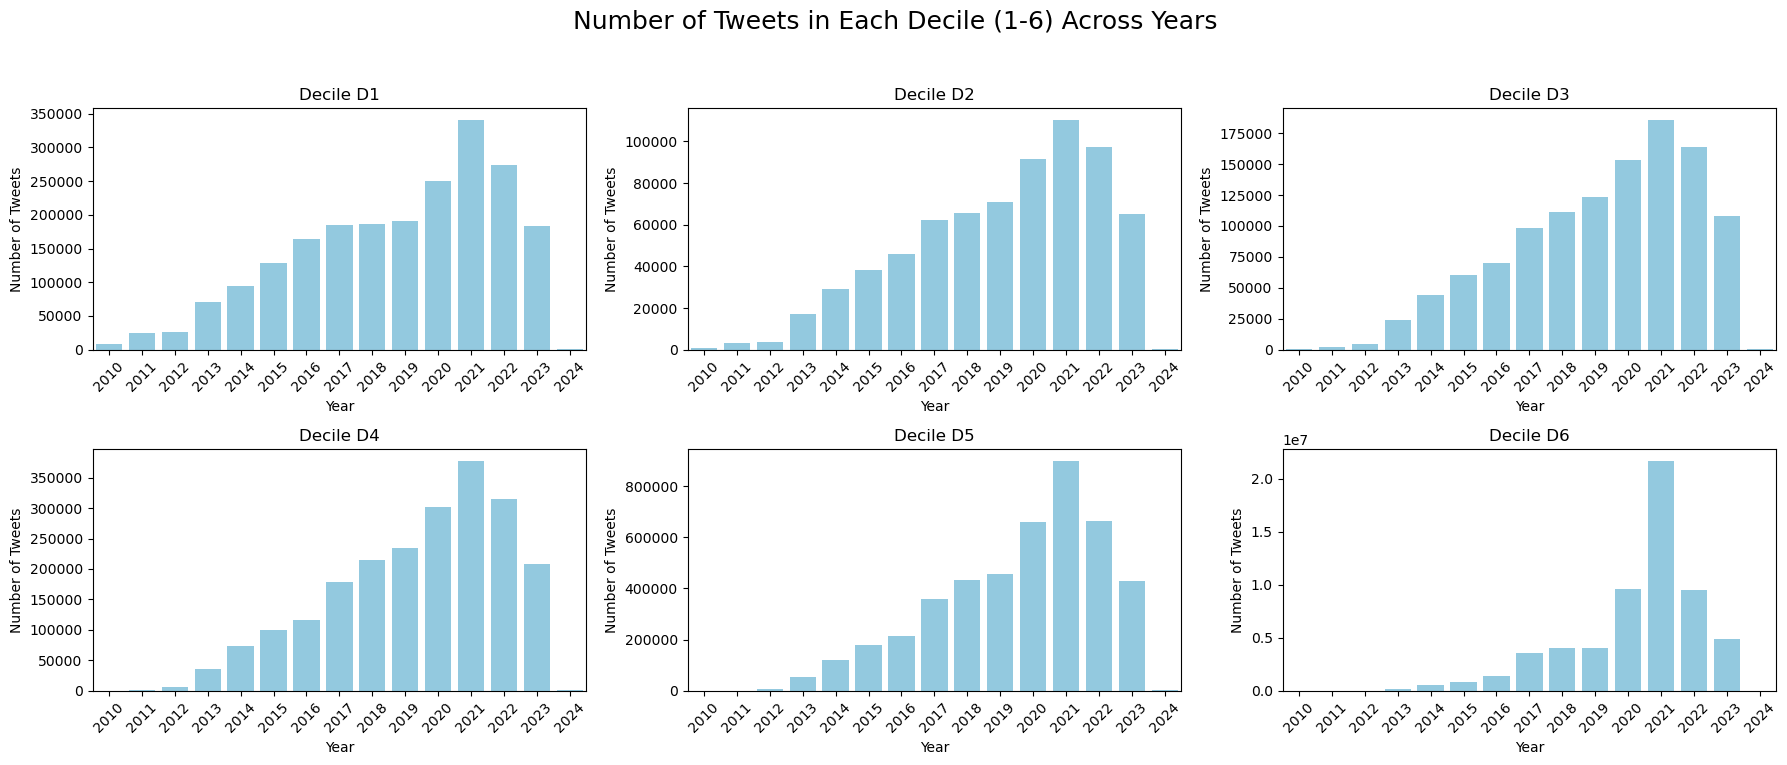

In [65]:
# Plot number of tweets in each decile across years (2x3 grid, deciles 1-6 only)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure year column exists and is integer
df_reg['year'] = pd.to_datetime(df_reg['date']).dt.year.astype(int)

# Only use deciles 1-6
plot_deciles = [f'D{i}' for i in range(1, 7)]
tweet_counts = (
    df_reg[df_reg['tweet_decile'].isin(plot_deciles)]
    .groupby(['tweet_decile', 'year'])['n_tweets']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, decile in enumerate(plot_deciles):
    ax = axes[i]
    data = tweet_counts[tweet_counts['tweet_decile'] == decile]
    sns.barplot(x='year', y='n_tweets', data=data, ax=ax, color='skyblue')
    ax.set_title(f"Decile {decile}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Tweets')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Number of Tweets in Each Decile (1-6) Across Years', fontsize=18)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [70]:
# Show top 10 most popular stocks for each decile (by total tweets)
for decile in [f'D{i}' for i in range(1, 7)]:
    print(f"\nTop 10 stocks in Decile {decile} (by total tweets):")
    df_dec = df_reg[df_reg['tweet_decile'] == decile]
    if 'symbol' not in df_dec.columns:
        print("No 'symbol' column found in the data.")
        continue
    top_stocks = (
        df_dec.groupby('symbol', as_index=False)['n_tweets']
        .sum()
        .sort_values('n_tweets', ascending=False)
        .head(10)
    )
    if top_stocks.empty:
        print("No data for this decile.")
    else:
        for idx, row in top_stocks.iterrows():
            print(f"{row['symbol']}: {row['n_tweets']:,} tweets")


Top 10 stocks in Decile D1 (by total tweets):
VLO: 1,689 tweets
LVS: 1,678 tweets
SIRI: 1,609 tweets
EOG: 1,583 tweets
CF: 1,578 tweets
MA: 1,571 tweets
HPQ: 1,570 tweets
ISRG: 1,567 tweets
AXP: 1,560 tweets
SLB: 1,559 tweets

Top 10 stocks in Decile D2 (by total tweets):
CAT: 990 tweets
GS: 960 tweets
LULU: 960 tweets
AA: 921 tweets
SIRI: 918 tweets
IBM: 918 tweets
EBAY: 879 tweets
FSLR: 873 tweets
EXAS: 867 tweets
WFC: 849 tweets

Top 10 stocks in Decile D3 (by total tweets):
VLO: 1,689 tweets
LVS: 1,678 tweets
SIRI: 1,609 tweets
EOG: 1,583 tweets
CF: 1,578 tweets
MA: 1,571 tweets
HPQ: 1,570 tweets
ISRG: 1,567 tweets
AXP: 1,560 tweets
SLB: 1,559 tweets

Top 10 stocks in Decile D2 (by total tweets):
CAT: 990 tweets
GS: 960 tweets
LULU: 960 tweets
AA: 921 tweets
SIRI: 918 tweets
IBM: 918 tweets
EBAY: 879 tweets
FSLR: 873 tweets
EXAS: 867 tweets
WFC: 849 tweets

Top 10 stocks in Decile D3 (by total tweets):
GS: 2,063 tweets
CAT: 2,047 tweets
FSLR: 2,023 tweets
C: 2,008 tweets
IBM: 1,96

In [69]:
# Check columns of df_reg to find ticker column
print(df_reg.columns.tolist())
print(df_reg.head())

['symbol', 'date', 'permno', 'n_tweets', 'n_bullish', 'n_bearish', 'ar_dgtw_1', 'ar_dgtw_3', 'ar_dgtw_5', 'ar_dgtw_10', 'ar_dgtw_21', 'ar_dgtw_42', 'ar_dgtw_63', 'ar_capm_1', 'ar_capm_3', 'ar_capm_5', 'ar_capm_10', 'ar_capm_21', 'ar_capm_42', 'ar_capm_63', 'ar_FF3_1', 'ar_FF3_3', 'ar_FF3_5', 'ar_FF3_10', 'ar_FF3_21', 'ar_FF3_42', 'ar_FF3_63', 'ar_FF5_1', 'ar_FF5_3', 'ar_FF5_5', 'ar_FF5_10', 'ar_FF5_21', 'ar_FF5_42', 'ar_FF5_63', 'ar_FF6_1', 'ar_FF6_3', 'ar_FF6_5', 'ar_FF6_10', 'ar_FF6_21', 'ar_FF6_42', 'ar_FF6_63', 'pct_bullish', 'pct_bearish', 'sentiment_score', 'AF_sentiment_score', 'year_month', 'cluster_var', 'year', 'date_str', 'cluster_var_day', 'tweet_decile']
  symbol       date   permno  n_tweets  n_bullish  n_bearish  ar_dgtw_1  \
0      A 2010-12-16  87432.0         1          1          0   0.007135   
1      A 2010-12-27  87432.0         1          1          0  -0.007403   
2     AA 2010-08-24  24643.0         1          0          1   0.001572   
3     AA 2010-08-31  246

Creating binned scatter plots for deciles: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']
Plotting 'ar_FF5_1' vs 'sentiment_score'


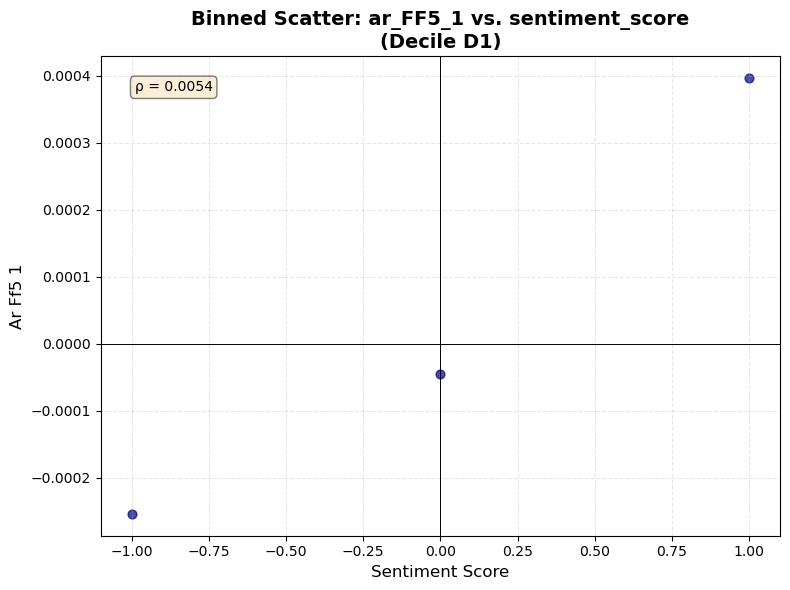

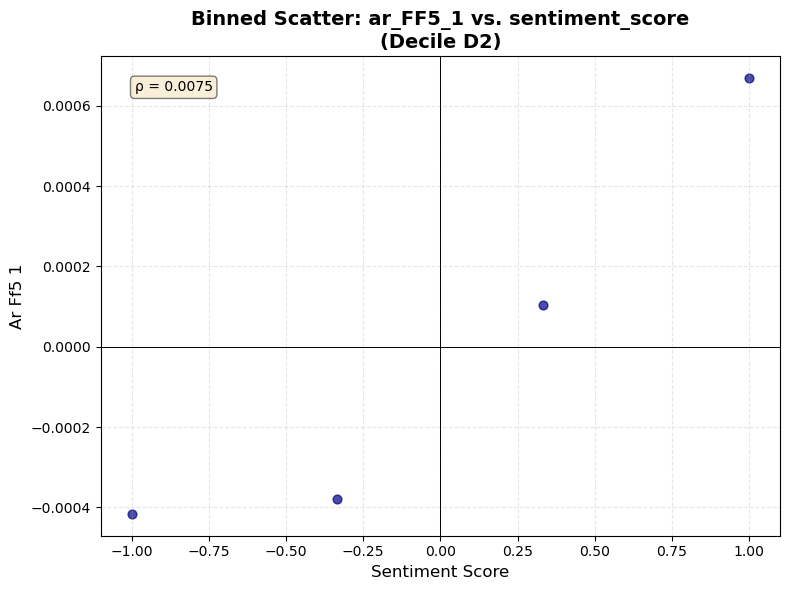

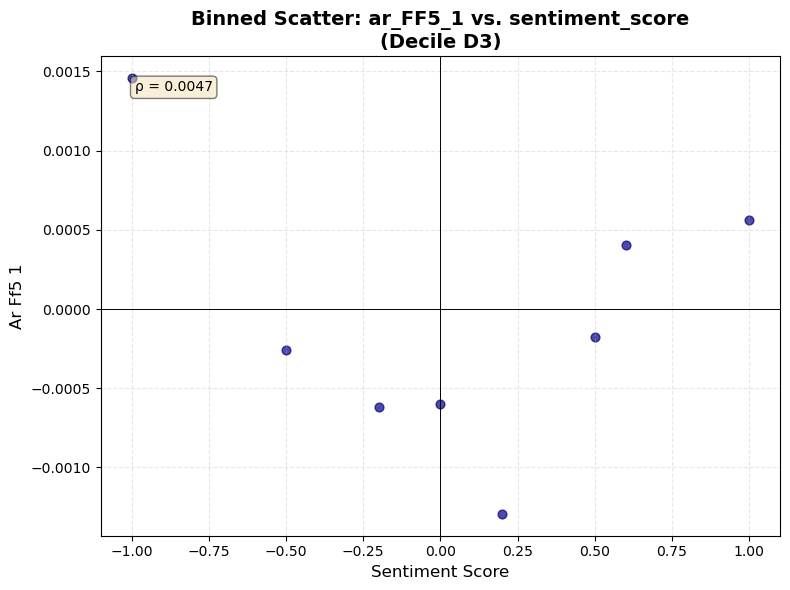

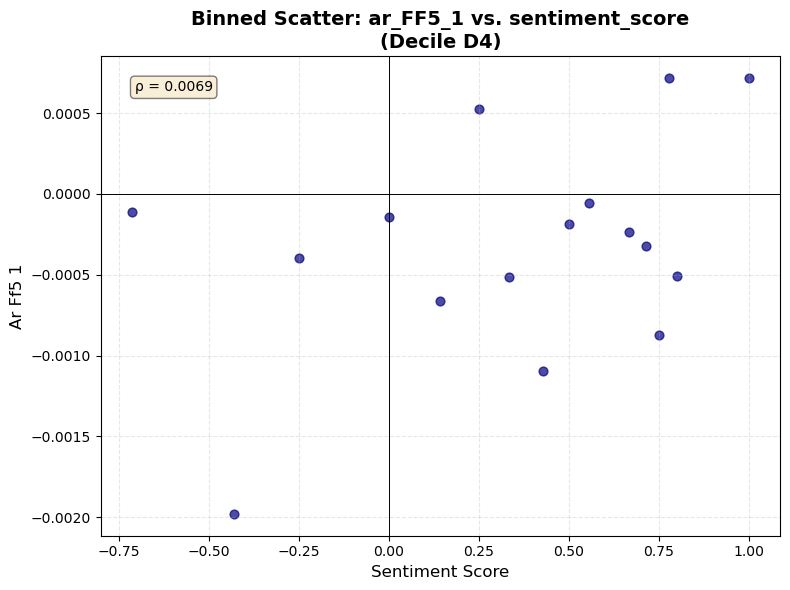

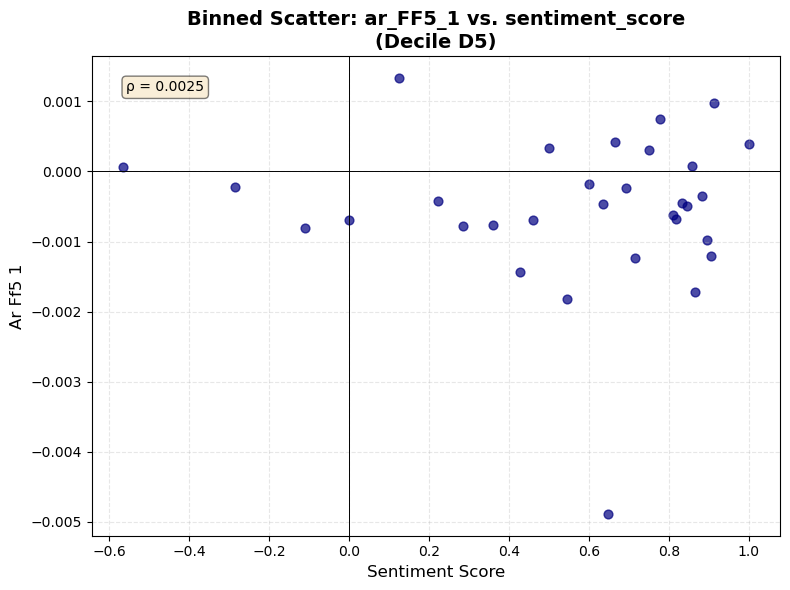

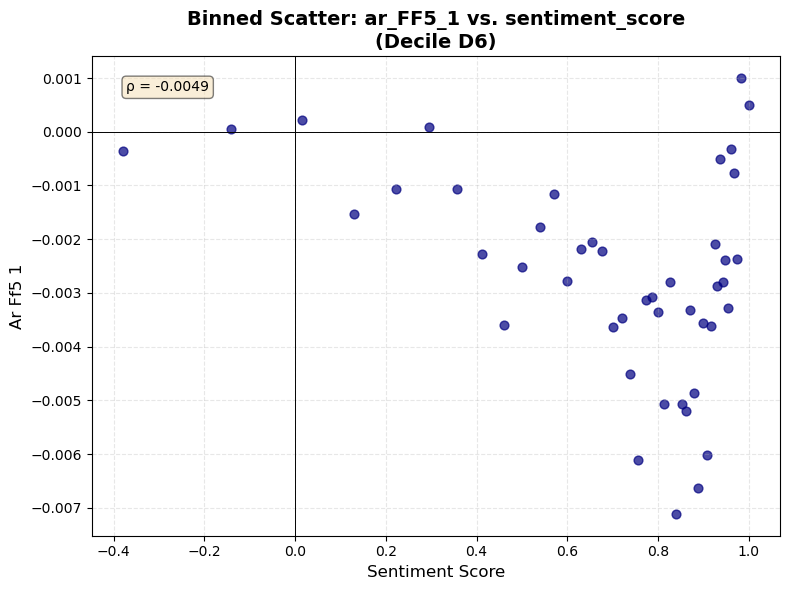

In [73]:
# Binned scatter plots of abnormal returns vs sentiment for each decile
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# Choose the abnormal return column and sentiment column to plot
ar_col = 'ar_FF5_1'
sent_col = 'sentiment_score'  # or 'AF_sentiment_score'
# -------------------

# Get the deciles that actually exist in the data
deciles_to_plot = sorted(df_reg['tweet_decile'].dropna().unique())

print(f"Creating binned scatter plots for deciles: {deciles_to_plot}")
print(f"Plotting '{ar_col}' vs '{sent_col}'")

for decile in deciles_to_plot:
    df_dec = df_reg[df_reg['tweet_decile'] == decile]
    
    if df_dec.empty:
        print(f"\nSkipping Decile {decile} as it is empty.")
        continue
        
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    
    sns.regplot(
        data=df_dec,
        x=sent_col,
        y=ar_col,
        x_bins=50,          # Create 50 bins for the x-axis
        fit_reg=False,      # Do not plot a regression line
        ci=None,            # Do not plot a confidence interval
        scatter_kws={'alpha': 0.7, 's': 40, 'color': 'navy'},
        ax=ax
    )
    
    # Formatting
    ax.set_title(f'Binned Scatter: {ar_col} vs. {sent_col}\n(Decile {decile})', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{sent_col.replace("_", " ").title()}', fontsize=12)
    ax.set_ylabel(f'{ar_col.replace("_", " ").title()}', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.7)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.7)
    
    # Add correlation
    corr = df_dec[sent_col].corr(df_dec[ar_col])
    ax.text(0.05, 0.95, f'ρ = {corr:.4f}', 
            transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()